In [123]:
filepath_input = "/Projet_Moustafa_Datascience/aug25cds_variabilite/data/local_data/04_Features_engineering/output/"
filepath_output = "/Projet_Moustafa_Datascience/aug25cds_variabilite/data/local_data/05_Modelisation/output/"

In [124]:
# !pip install lazypredict
import numpy as np
import pandas as pd
from scipy.stats import uniform, randint, loguniform

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from lightgbm import LGBMRegressor, plot_tree
from xgboost import XGBRegressor
from lazypredict.Supervised import LazyRegressor

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle
import joblib
import cloudpickle

In [200]:
# print("Train :")
# train = pd.read_csv(filepath_input + "train_region.csv", index_col='datetime_utc', parse_dates=True)
# display(train.head(2))
# print("Taille du dataset :", train.shape)

# print("\nValid :")
# valid = pd.read_csv(filepath_input + "valid_region.csv", index_col='datetime_utc', parse_dates=True)
# display(valid.head(2))
# print("Taille du dataset :", valid.shape)

# print("\nTest :")
# test = pd.read_csv(filepath_input + "test_region.csv", index_col='datetime_utc', parse_dates=True)
# display(test.head(2))
# print("Taille du dataset :", test.shape)

train = pd.read_csv(filepath_input + "train_region.csv", index_col='datetime_utc', parse_dates=True)
valid = pd.read_csv(filepath_input + "valid_region.csv", index_col='datetime_utc', parse_dates=True)
test = pd.read_csv(filepath_input + "test_region.csv", index_col='datetime_utc', parse_dates=True)

test = valid.loc["2024-01-01 00:00:00+00:00":]
valid = valid.loc["2023-01-01 00:00:00+00:00":"2023-12-31 23:30:00+00:00"]
train = train.loc[:"2022-12-31 23:30:00+00:00"]

print("Train :")
print("Taille du dataset :", train.shape)

print("\nValid :")
print("Taille du dataset :", valid.shape)

print("\nTest :")
print("Taille du dataset :", test.shape)


display(train.head(-1))
display(valid.head(-1))
display(test.head(-1))

X_train = train.drop(['target'], axis=1)
y_train = train["target"]

# X_valid = valid.drop(['target'], axis=1)
X_valid = valid.drop(['target'], axis=1)
y_valid = valid["target"]

# X_test = test.drop(['target'], axis=1)
X_test = test.drop(['target'], axis=1)
y_test = test["target"]


Train :
Taille du dataset : (52602, 149)

Valid :
Taille du dataset : (17513, 149)

Test :
Taille du dataset : (17567, 149)


,abs_dtch_lag_1,abs_dtch_lag_2,abs_dtch_lag_3,abs_dtch_lag_4,abs_dtch_lag_6,abs_dtch_roll_mean_3h,abs_dtch_roll_mean_4h,abs_dtch_roll_mean_6h,abs_dtch_roll_std_3h,abs_dtch_roll_std_4h,...,region_nebulosite_lag_6,region_nebulosite_roll_mean_3h,region_nebulosite_roll_mean_4h,region_nebulosite_roll_mean_6h,region_nebulosite_roll_std_3h,region_nebulosite_roll_std_4h,region_nebulosite_roll_std_6h,region_temperature,region_toa,region_vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 02:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,24.56,11.39,9.85,13.31,7.47,6.89,8.53,3.52,0.00,1.05
2020-01-01 03:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,25.25,19.95,16.58,14.46,12.21,12.05,10.50,3.36,0.00,0.97
2020-01-01 03:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,15.23,28.11,23.02,17.30,7.08,11.71,12.72,3.26,0.00,0.97
2020-01-01 04:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,5.22,32.22,29.15,21.80,0.37,6.16,12.36,3.17,0.00,0.97
2020-01-01 04:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,6.48,32.36,32.31,26.15,0.67,0.61,10.31,3.23,0.00,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 20:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,...,47.72,42.09,41.67,41.26,2.10,3.08,7.90,10.25,0.00,3.55
2022-12-31 21:00:00+00:00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,...,40.48,42.64,42.32,41.68,2.68,2.59,5.09,10.30,0.00,3.55
2022-12-31 21:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,40.44,42.08,42.13,41.71,4.56,4.28,4.42,10.30,0.00,3.55


,abs_dtch_lag_1,abs_dtch_lag_2,abs_dtch_lag_3,abs_dtch_lag_4,abs_dtch_lag_6,abs_dtch_roll_mean_3h,abs_dtch_roll_mean_4h,abs_dtch_roll_mean_6h,abs_dtch_roll_std_3h,abs_dtch_roll_std_4h,...,region_nebulosite_lag_6,region_nebulosite_roll_mean_3h,region_nebulosite_roll_mean_4h,region_nebulosite_roll_mean_6h,region_nebulosite_roll_std_3h,region_nebulosite_roll_std_4h,region_nebulosite_roll_std_6h,region_temperature,region_toa,region_vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2023-01-01 03:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,30.09,40.38,40.68,37.03,3.41,3.66,7.66,9.80,0.00,2.92
2023-01-01 04:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,25.78,43.58,42.61,40.95,5.73,5.29,6.30,9.75,0.00,2.85
2023-01-01 04:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,33.68,49.49,46.58,44.60,6.09,7.66,7.18,9.77,0.00,2.82
2023-01-01 05:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,41.57,55.59,52.59,47.98,6.58,8.09,9.62,9.79,0.00,2.78
2023-01-01 05:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,39.71,60.37,57.60,51.97,4.77,6.98,10.45,9.71,0.00,2.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,41.25,55.66,51.37,45.70,10.79,13.68,18.50,4.29,0.00,2.48
2023-12-31 21:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,36.65,64.97,59.97,51.74,9.72,12.99,19.01,3.93,0.00,2.48
2023-12-31 22:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,32.05,72.88,68.58,59.63,8.44,12.01,18.36,3.57,0.00,2.48


,abs_dtch_lag_1,abs_dtch_lag_2,abs_dtch_lag_3,abs_dtch_lag_4,abs_dtch_lag_6,abs_dtch_roll_mean_3h,abs_dtch_roll_mean_4h,abs_dtch_roll_mean_6h,abs_dtch_roll_std_3h,abs_dtch_roll_std_4h,...,region_nebulosite_lag_6,region_nebulosite_roll_mean_3h,region_nebulosite_roll_mean_4h,region_nebulosite_roll_mean_6h,region_nebulosite_roll_std_3h,region_nebulosite_roll_std_4h,region_nebulosite_roll_std_6h,region_temperature,region_toa,region_vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,66.37,88.06,86.50,83.05,3.79,4.50,8.04,2.66,0.00,2.48
2024-01-01 00:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,72.88,91.34,89.57,86.58,3.11,4.36,5.97,2.58,0.00,2.46
2024-01-01 01:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,79.39,94.10,92.59,89.41,2.32,3.62,5.83,2.50,0.00,2.44
2024-01-01 01:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,81.83,96.07,95.02,92.07,2.09,2.79,5.23,2.48,0.00,2.39
2024-01-01 02:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,84.27,97.78,96.86,94.56,1.84,2.57,4.37,2.45,0.00,2.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 20:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,30.17,46.70,45.06,41.86,2.51,4.20,6.54,4.19,0.00,0.81
2024-12-31 21:00:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,33.89,47.63,46.77,44.04,1.21,2.21,5.16,4.10,0.00,0.84
2024-12-31 21:30:00+00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,37.01,48.42,48.38,46.31,2.37,2.40,4.21,4.06,0.00,0.83


In [ ]:
features = ['consommation',
 'cos_doy',
 'cos_hour',
 'dtch_roll_mean_12h',
 'dtch_roll_mean_24h',
 'dtch_roll_mean_3h',
 'dtch_roll_mean_48h',
 'dtch_roll_mean_6h',
 'dtch_roll_std_12h',
 'dtch_roll_std_24h',
 'dtch_roll_std_3h',
 'dtch_roll_std_48h',
 'dtch_roll_std_6h',
 'sin_doy',
 'sin_hour',
 'solaire',
 'target',
 'target_lag_1',
 'target_lag_12',
 'target_lag_2',
 'target_lag_24',
 'target_lag_3',
 'target_lag_48',
 'target_lag_6',
 'tch_lag_1',
 'tch_lag_12',
 'tch_lag_2',
 'tch_lag_24',
 'tch_lag_3',
 'tch_lag_48',
 'tch_lag_6',
 'tch_roll_mean_12h',
 'tch_roll_mean_24h',
 'tch_roll_mean_3h',
 'tch_roll_mean_48h',
 'tch_roll_mean_6h',
 'tch_roll_std_12h',
 'tch_roll_std_24h',
 'tch_roll_std_3h',
 'tch_roll_std_48h',
 'tch_roll_std_6h',
 'tch_solaire',
 'tco_solaire',
 'region_altitude',
 'region_azimuth',
 'region_bhi',
 'region_bni',
 'region_clear_sky_bhi',
 'region_clear_sky_bni',
 'region_clear_sky_dhi',
 'region_clear_sky_ghi',
 'region_dghi_dt',
 'region_dghi_lag_1',
 'region_dghi_lag_12',
 'region_dghi_lag_2',
 'region_dghi_lag_24',
 'region_dghi_lag_3',
 'region_dghi_lag_48',
 'region_dghi_lag_6',
 'region_dghi_roll_mean_12h',
 'region_dghi_roll_mean_24h',
 'region_dghi_roll_mean_3h',
 'region_dghi_roll_mean_48h',
 'region_dghi_roll_mean_6h',
 'region_dghi_roll_std_12h',
 'region_dghi_roll_std_24h',
 'region_dghi_roll_std_3h',
 'region_dghi_roll_std_48h',
 'region_dghi_roll_std_6h',
 'region_dhi',
 'region_dnebulosite_dt',
 'region_dnebulosite_lag_1',
 'region_dnebulosite_lag_12',
 'region_dnebulosite_lag_2',
 'region_dnebulosite_lag_24',
 'region_dnebulosite_lag_3',
 'region_dnebulosite_lag_48',
 'region_dnebulosite_lag_6',
 'region_dnebulosite_roll_mean_12h',
 'region_dnebulosite_roll_mean_24h',
 'region_dnebulosite_roll_mean_3h',
 'region_dnebulosite_roll_mean_48h',
 'region_dnebulosite_roll_mean_6h',
 'region_dnebulosite_roll_std_12h',
 'region_dnebulosite_roll_std_24h',
 'region_dnebulosite_roll_std_3h',
 'region_dnebulosite_roll_std_48h',
 'region_dnebulosite_roll_std_6h',
 'region_ghi',
 'region_ghi_lag_1',
 'region_ghi_lag_12',
 'region_ghi_lag_2',
 'region_ghi_lag_24',
 'region_ghi_lag_3',
 'region_ghi_lag_48',
 'region_ghi_lag_6',
 'region_ghi_roll_mean_12h',
 'region_ghi_roll_mean_24h',
 'region_ghi_roll_mean_3h',
 'region_ghi_roll_mean_48h',
 'region_ghi_roll_mean_6h',
 'region_ghi_roll_std_12h',
 'region_ghi_roll_std_24h',
 'region_ghi_roll_std_3h',
 'region_ghi_roll_std_48h',
 'region_ghi_roll_std_6h',
 'region_humidite',
 'region_nebulosite',
 'region_nebulosite_lag_1',
 'region_nebulosite_lag_12',
 'region_nebulosite_lag_2',
 'region_nebulosite_lag_24',
 'region_nebulosite_lag_3',
 'region_nebulosite_lag_48',
 'region_nebulosite_lag_6',
 'region_nebulosite_roll_mean_12h',
 'region_nebulosite_roll_mean_24h',
 'region_nebulosite_roll_mean_3h',
 'region_nebulosite_roll_mean_48h',
 'region_nebulosite_roll_mean_6h',
 'region_nebulosite_roll_std_12h',
 'region_nebulosite_roll_std_24h',
 'region_nebulosite_roll_std_3h',
 'region_nebulosite_roll_std_48h',
 'region_nebulosite_roll_std_6h',
 'region_temperature',
 'region_toa',
 'region_vitesse_vent',
 'abs_dghi',
 'ghi_mean_3h',
 'ghi_std_3h',
 'ghi_cv',
 'csi']

features_clean = [
    # Temps
    'sin_hour', 'cos_hour',
    'sin_doy', 'cos_doy',

    # Physique solaire
    'region_ghi',
    'region_dhi',
    'region_bni',
    'region_clear_sky_ghi',
    'region_toa',

    # Météo
    'region_nebulosite',
    'region_temperature',
    'region_humidite',
    'region_vitesse_vent',

    # Variations
    'region_dghi_dt',
    'region_dnebulosite_dt',
    'abs_dghi',

    # Lags réduits
    'region_ghi_lag_1',
    'region_ghi_lag_3',
    'region_ghi_lag_6',
    'region_ghi_lag_24',

    # Rolling réduits
    'region_ghi_roll_mean_3h',
    'region_ghi_roll_std_3h',
    'region_ghi_roll_mean_24h',
    'region_ghi_roll_std_24h',

    # Features robustes
    'ghi_cv',
    'csi'
]

features_clean += [
    # # mémoire du système (IMPORTANT)
    'tch_lag_1',
    'tch_lag_3',

    # rolling léger (utile)
    'tch_roll_mean_3h',
    'tch_roll_std_3h',
    # # mémoire du système (IMPORTANT)
    'target_lag_1',
    'target_lag_3',

    # rolling léger (utile)
    'dtch_roll_mean_3h',
    'dtch_roll_std_3h',

    # variation locale
    'region_dghi_lag_1',

    'region_ghi_roll_std_6h',   # variabilité locale plus large
    'region_dghi_roll_std_3h',  # variation rapide
    'region_nebulosite_roll_std_3h'  # instabilité nuages
]

features_clean += [
    'high_ghi',
    'ghi_high_interaction'
]

In [ ]:

# Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_valid_lgbm = pd.concat([X_train, X_valid])
y_train_valid_lgbm = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_lgbm = X_test.copy()
y_test_lgbm = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
# best_params_lgbm = search_lgbm.best_params_

# Initialisation du modèle LightGBM de régression
final_lgbm = LGBMRegressor(
    n_jobs=-1,
    random_state=42,
    bagging_freq=1,
    # **best_params_lgbm
)

# Entraînement du modèle
final_lgbm.fit(X_train_valid_lgbm, y_train_valid_lgbm)

# Prédiction sur le jeu de test/train
y_pred_lgbm = final_lgbm.predict(X_test_lgbm)
y_pred_train_valid_lgbm = final_lgbm.predict(X_train_valid_lgbm)

# Évaluation
mae_lgbm = mean_absolute_error(y_test_lgbm, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_lgbm, y_pred_lgbm))
r2_test_lgbm = r2_score(y_test_lgbm, y_pred_lgbm)
r2_train_valid_lgbm = r2_score(y_train_valid_lgbm, y_pred_train_valid_lgbm)
mae_rel_lgbm = mae_lgbm / y_test_lgbm.mean() * 100

print("\n--- Résultats LGBM ---")
print("MAE               :", mae_lgbm)
print(f"MAE relatif      : {round(mae_rel_lgbm, 3)}%")
print("RMSE              :", rmse_lgbm)
print("R² train_valid    :", r2_train_valid_lgbm)
print("R² test           :", r2_test_lgbm)


[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.190530 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37301
[LightGBM] [Info] Number of data points in the train set: 87682, number of used features: 148
[LightGBM] [Info] Start training from score 2.434615
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1

--- Résultats LGBM ---
MAE               : 0.7661833481500533
MAE relatif      : 32.643%
RMSE              : 1.4614603585100303
R² train_valid    : 0.9309418974851229
R² test           : 0.8018014515223272


In [ ]:

pd.Series(
        final_lgbm.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).index.to_list()

['target_lag_1',
 'dtch_roll_mean_48h',
 'dtch_roll_std_3h',
 'region_dhi',
 'target_lag_48',
 'region_dghi_roll_std_3h',
 'region_dnebulosite_dt',
 'region_dghi_dt',
 'csi',
 'region_dghi_roll_mean_48h',
 'region_nebulosite',
 'dtch_roll_std_6h',
 'tco_solaire',
 'region_dnebulosite_roll_mean_3h',
 'target_lag_2',
 'region_dghi_lag_3',
 'region_dghi_lag_2',
 'region_clear_sky_bhi',
 'tch_solaire',
 'region_clear_sky_bni',
 'region_dghi_lag_1',
 'region_dnebulosite_roll_mean_48h',
 'region_clear_sky_dhi',
 'region_dghi_roll_std_6h',
 'dtch_roll_std_12h',
 'abs_dghi',
 'tch_lag_1',
 'target_lag_3',
 'region_dghi_lag_48',
 'solaire',
 'region_bni',
 'tch_roll_std_3h',
 'region_clear_sky_ghi',
 'region_humidite',
 'region_vitesse_vent',
 'region_ghi_roll_std_3h',
 'dtch_roll_mean_24h',
 'target_lag_6',
 'region_dnebulosite_roll_std_3h',
 'region_temperature',
 'region_toa',
 'region_azimuth',
 'region_dghi_roll_mean_3h',
 'region_dnebulosite_lag_24',
 'region_dghi_lag_6',
 'region_dnebulo

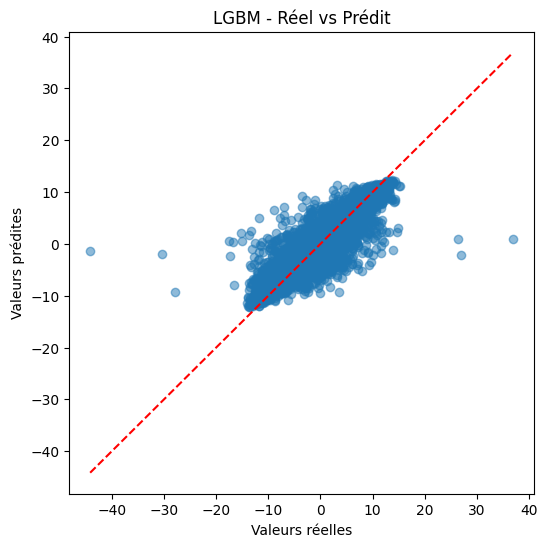

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_lgbm, y_pred_lgbm, alpha=0.5)
plt.plot([y_test_lgbm.min(), y_test_lgbm.max()],
         [y_test_lgbm.min(), y_test_lgbm.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
# plt.xlim(-20,20)
# plt.ylim(-20,20)
plt.title("LGBM - Réel vs Prédit")
plt.show()

In [ ]:

X_tr = X_train.loc[: "2021-12-31 23:30:00+00:00"]
y_tr = y_train.loc[: "2021-12-31 23:30:00+00:00"]

X_val = X_train.loc["2022-01-01 00:00:00+00:00" :]
y_val = y_train.loc["2022-01-01 00:00:00+00:00" :]

# LazyRegressor + MAE + MAE relatif
def run_lazy(X_train, X_valid, y_train, y_valid):
    """Fonction qui exécute LazyPredict sur un jeu d'entraînement et de validation
    et qui calcule en plus le MAE et le MAE relatif (%)"""

    # Initialisation de LazyRegressor
    reg = LazyRegressor(verbose=1, ignore_warnings=True, random_state=42, predictions=True)

    # Entraîne tous les modèles de LazyPredict
    # models : tableau contenant les métriques calculées par LazyPredict
    # preds : DataFrame contenant les prédictions de chaque modèle
    models, preds = reg.fit(X_train, X_valid, y_train, y_valid)

    # Calcul de la moyenne des valeurs réelles de validation
    # utilisée pour calculer le MAE relatif
    y_mean = y_valid.mean()

    # Dictionnaires pour stocker les scores
    mae_scores = {}
    mae_rel_scores = {}

    # Boucle sur chaque modèle testé
    for model_name in preds.columns:
        # Prédictions du modèle courant
        pred = preds[model_name]

        # Calcul du MAE (Mean Absolute Error)
        mae = mean_absolute_error(y_valid, pred)

        # Calcul du MAE relatif en pourcentage
        mae_rel = round(mae / y_mean * 100, 2) if y_mean != 0 else np.nan

        # Stockage des résultats
        mae_scores[model_name] = mae
        mae_rel_scores[model_name] = mae_rel

    # Conversion des dictionnaires en DataFrame
    mae_df = pd.DataFrame({
        "MAE": pd.Series(mae_scores),
        "MAE_relatif(%)": pd.Series(mae_rel_scores)
    })

    # Fusion des scores MAE avec les résultats fournis par LazyPredict
    # l'index correspond au nom des modèles
    out = models.merge(mae_df, left_index=True, right_index=True)

    # # Ajout d'une colonne indiquant si les données sont scalées ou non
    # out["scaling_mode"] = label

    return out


# Exécuter LazyPredict sur les données non scalées
models_df = run_lazy(X_tr, X_val, y_tr, y_val)

# Renommer certaines colonnes pour avoir des noms plus explicites
models_df = models_df.rename({
    "R-Squared": "r2_score",
    "Time Taken": "temps_execution"
}, axis=1)

# Sélectionner uniquement les colonnes utiles pour l'analyse
models_df = models_df[
    ["r2_score", "MAE", "RMSE", "MAE_relatif(%)", "temps_execution"]
]

# Sauvegarde les résultats de LazyPredict dans un fichier CSV
# pour éviter de relancer l'entraînement (qui prend du temps)
models_df.reset_index(names="Model").to_csv("models_lazy_predict.csv", index=False)
models_df.reset_index(names="Model").set_index('Model').head()
models_df.loc[models_df["r2_score"] > 0].sort_values(["MAE", "r2_score"], ascending=[True, False]).head(40)

  0%|          | 0/42 [00:00<?, ?it/s]

,r2_score,MAE,RMSE,MAE_relatif(%),temps_execution
ExtraTreesRegressor,0.920208,0.430433,0.949756,17.22,66.629876
RandomForestRegressor,0.918600,0.437720,0.959279,17.51,360.138814
NuSVR,0.919224,0.454846,0.955595,18.20,221.654063
SVR,0.919283,0.458878,0.955242,18.36,93.273925
HistGradientBoostingRegressor,0.917090,0.460549,0.968133,18.43,1.120974
LGBMRegressor,0.916402,0.461968,0.972143,18.48,1.083384
BaggingRegressor,0.909608,0.466368,1.010871,18.66,36.513947
XGBRegressor,0.905864,0.487394,1.031595,19.50,1.630346
GradientBoostingRegressor,0.907828,0.504636,1.020779,20.19,137.514678
KNeighborsRegressor,0.896945,0.530493,1.079359,21.22,1.808561


In [ ]:
# Sauvegarde les résultats de LazyPredict dans un fichier CSV
# pour éviter de relancer l'entraînement (qui prend du temps)
filepath_output = '/content/drive/MyDrive/aug25cds_variabilite/data/local_data/05_Modelisation/output/'
models_df.reset_index(names="Model").to_csv(filepath_output + "models_lazy_predict.csv", index=False)
models_df.reset_index(names="Model").set_index('Model').head()
models_df.loc[models_df["r2_score"] > 0].sort_values(["MAE", "r2_score"], ascending=[True, False]).head(40)

In [ ]:
# Sauvegarde les résultats de LazyPredict dans un fichier CSV
# pour éviter de relancer l'entraînement (qui prend du temps)
filepath_output = '/content/drive/MyDrive/aug25cds_variabilite/data/local_data/05_Modelisation/output/'
models_df.reset_index(names="Model").to_csv(filepath_output + "models_lazy_predict.csv", index=False)
models_df.reset_index(names="Model").set_index('Model').head()
models_df.loc[models_df["r2_score"] > 0].sort_values(["MAE", "r2_score"], ascending=[True, False]).head(40)

,r2_score,MAE,RMSE,MAE_relatif(%),temps_execution
ExtraTreesRegressor,0.920208,0.430433,0.949756,17.22,66.629876
RandomForestRegressor,0.918600,0.437720,0.959279,17.51,360.138814
NuSVR,0.919224,0.454846,0.955595,18.20,221.654063
SVR,0.919283,0.458878,0.955242,18.36,93.273925
HistGradientBoostingRegressor,0.917090,0.460549,0.968133,18.43,1.120974
LGBMRegressor,0.916402,0.461968,0.972143,18.48,1.083384
BaggingRegressor,0.909608,0.466368,1.010871,18.66,36.513947
XGBRegressor,0.905864,0.487394,1.031595,19.50,1.630346
GradientBoostingRegressor,0.907828,0.504636,1.020779,20.19,137.514678
KNeighborsRegressor,0.896945,0.530493,1.079359,21.22,1.808561


| Catégorie                          | Idée                                                         |
| ---------------------------------- | ------------------------------------------------------------ |
| **Modèles linéaires**              | supposent une relation linéaire entre variables              |
| **Machines à vecteurs de support (SVM)** | modèles non linéaires utilisant des noyaux                   |
| **Arbres de décision**             | règles de décision successives (tests sur les variables)     |
| **Ensembles d’arbres**             | combinaison de plusieurs arbres pour améliorer la prédiction (RandomForest, XGBoost…) |
| **Réseaux de neurones**            | modèles non linéaires (MLPRegressor)                   |
| **Méthodes à base de voisins**     | prédiction basée sur les k échantillons d’apprentissage les plus proches (selon une distance) du nouveau point (KNN)       |
| **Méthodes particulières**                   | modèles utilisant des stratégies particulières d’apprentissage ou de transformation pour améliorer la prédiction (TransformedTargetRegressor, PassiveAggressiveRegressor)         |


In [ ]:
model_categories = {

# Modèles linéaires
'LinearRegression': 'Modèles linéaires',
'Ridge': 'Modèles linéaires',
'RidgeCV': 'Modèles linéaires',
'Lasso': 'Modèles linéaires',
'LassoCV': 'Modèles linéaires',
'ElasticNet': 'Modèles linéaires',
'ElasticNetCV': 'Modèles linéaires',
'BayesianRidge': 'Modèles linéaires',
'HuberRegressor': 'Modèles linéaires',
'SGDRegressor': 'Modèles linéaires',
'LarsCV': 'Modèles linéaires',
'LassoLars': 'Modèles linéaires',
'LassoLarsCV': 'Modèles linéaires',
'LassoLarsIC': 'Modèles linéaires',
'OrthogonalMatchingPursuit': 'Modèles linéaires',
'OrthogonalMatchingPursuitCV': 'Modèles linéaires',
'PoissonRegressor': 'Modèles linéaires',
'TweedieRegressor': 'Modèles linéaires',

# Machines à vecteurs de support
'SVR': 'SVM',
'NuSVR': 'SVM',
'LinearSVR': 'SVM',

# Arbres de décision
'DecisionTreeRegressor': 'Arbres de décision',
'ExtraTreeRegressor': 'Arbres de décision',

# Ensembles d’arbres
'RandomForestRegressor': 'Ensembles d’arbres',
'ExtraTreesRegressor': 'Ensembles d’arbres',
'GradientBoostingRegressor': 'Ensembles d’arbres',
'HistGradientBoostingRegressor': 'Ensembles d’arbres',
'XGBRegressor': 'Ensembles d’arbres',
'LGBMRegressor': 'Ensembles d’arbres',
'BaggingRegressor': 'Ensembles d’arbres',
'AdaBoostRegressor': 'Ensembles d’arbres',

# Réseaux de neurones
'MLPRegressor': 'Réseaux de neurones',

# Méthodes basées sur les voisins
'KNeighborsRegressor': 'Méthodes à base de voisins',

# Méta-modèles
'TransformedTargetRegressor': 'Méthodes particulières',
'PassiveAggressiveRegressor': 'Méthodes particulières'
}

models_df['Category'] = models_df.index.map(model_categories)
models_df.head()

,r2_score,MAE,RMSE,MAE_relatif(%),temps_execution,Category
ExtraTreesRegressor,0.920208,0.430433,0.949756,17.22,66.629876,Ensembles d’arbres
SVR,0.919283,0.458878,0.955242,18.36,93.273925,SVM
NuSVR,0.919224,0.454846,0.955595,18.20,221.654063,SVM
RandomForestRegressor,0.918600,0.437720,0.959279,17.51,360.138814,Ensembles d’arbres
HistGradientBoostingRegressor,0.917090,0.460549,0.968133,18.43,1.120974,Ensembles d’arbres


In [ ]:
category_performance = (
    models_df
    .loc[(models_df.r2_score > 0)].groupby('Category')[['MAE', 'r2_score']]
    .agg(['mean','median','std','min','max']).sort_values(by=('MAE','mean'))
    .fillna('')
)

display(category_performance)

MAE                                          \
                                mean    median       std       min       max   
Category                                                                       
SVM                         0.500261  0.458878  0.075196  0.454846  0.587058   
Méthodes à base de voisins  0.530493  0.530493            0.530493  0.530493   
Réseaux de neurones         0.591522  0.591522            0.591522  0.591522   
Arbres de décision          0.651150  0.651150  0.000092  0.651085  0.651215   
Ensembles d’arbres          0.678071  0.464168  0.605529  0.430433  2.175499   
Méthodes particulières      0.767856  0.767856   0.16306  0.652555  0.883157   
Modèles linéaires           0.871822  0.678198  0.359609  0.581216  1.671523   

                            r2_score                                          
                                mean    median       std       min       max  
Category                                                                      
SVM                         0.907515  0.919224  0.020331  0.884039  0.919283  
Méthodes à base de voisins  0.896945  0.896945            0.896945  0.896945  
Réseaux de neurones         0.906062  0.906062            0.906062  0.906062  
Arbres de décision          0.819048  0.819048  0.003505  0.816569  0.821526  
Ensembles d’arbres          0.861418  0.913005  0.147851  0.495742  0.920208  
Méthodes particulières      0.859883  0.859883  0.036205  0.834282  0.885484  
Modèles linéaires           0.822948  0.881546   0.10422  0.587425  0.889515

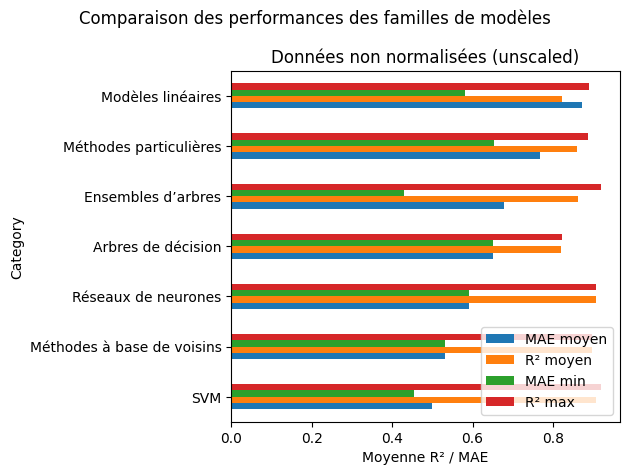

In [ ]:
# sélectionner la moyenne
unscaled_plot = category_performance[[('MAE','mean'), ('r2_score','mean'), ('MAE','min'), ('r2_score','max')]]

# renommer les colonnes pour un affichage plus propre
unscaled_plot.columns = ['MAE moyen', 'R² moyen', 'MAE min', 'R² max']

# graphique unscaled
unscaled_plot.plot(kind='barh')
plt.title('Données non normalisées (unscaled)')
plt.xlabel('Moyenne R² / MAE')

plt.suptitle('Comparaison des performances des familles de modèles')

plt.tight_layout()
plt.show()

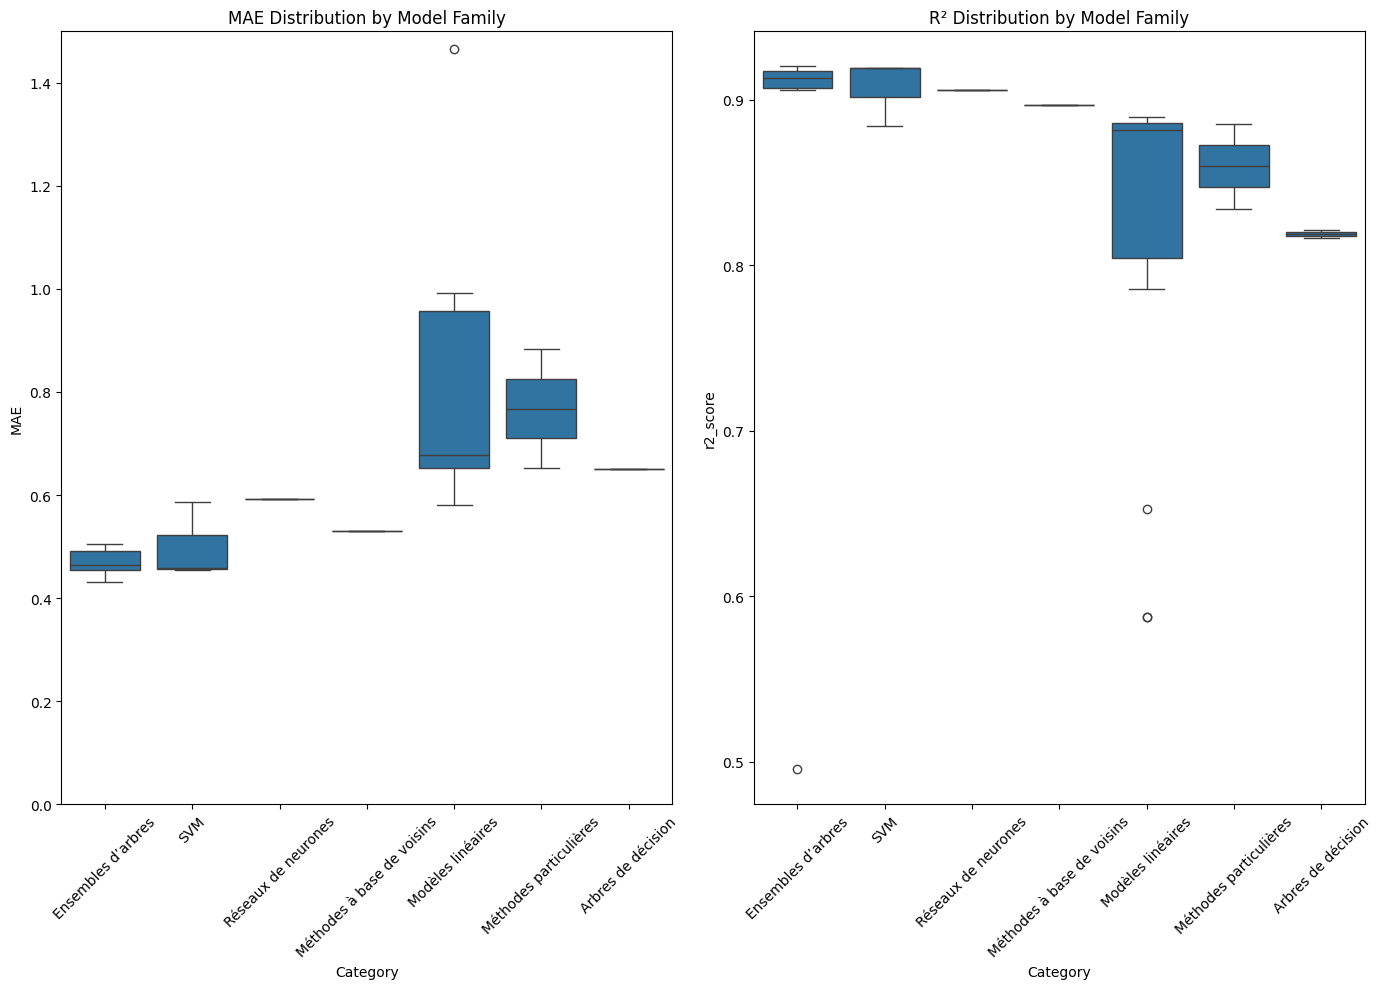

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14,10))

sns.boxplot(x='Category',
            y='MAE',
            data=models_df,
            ax=axes[0])
axes[0].set_title("MAE Distribution by Model Family")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1.5)

sns.boxplot(x='Category',
            y='r2_score',
            data=models_df,
            ax=axes[1])
axes[1].set_title("R² Distribution by Model Family")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## LGBMRegressor

In [6]:

def variables_importantes(model_class, X_train, y_train):
    """Calcule l'importance des variables pour un modèle donné."""

    # Instanciation du modèle
    model = model_class(random_state=42, n_jobs=-1)

    # Entraînement
    model.fit(X_train, y_train)

    # Récupération des importances
    importance = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    return importance


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37301
[LightGBM] [Info] Number of data points in the train set: 52602, number of used features: 148
[LightGBM] [Info] Start training from score 2.403531


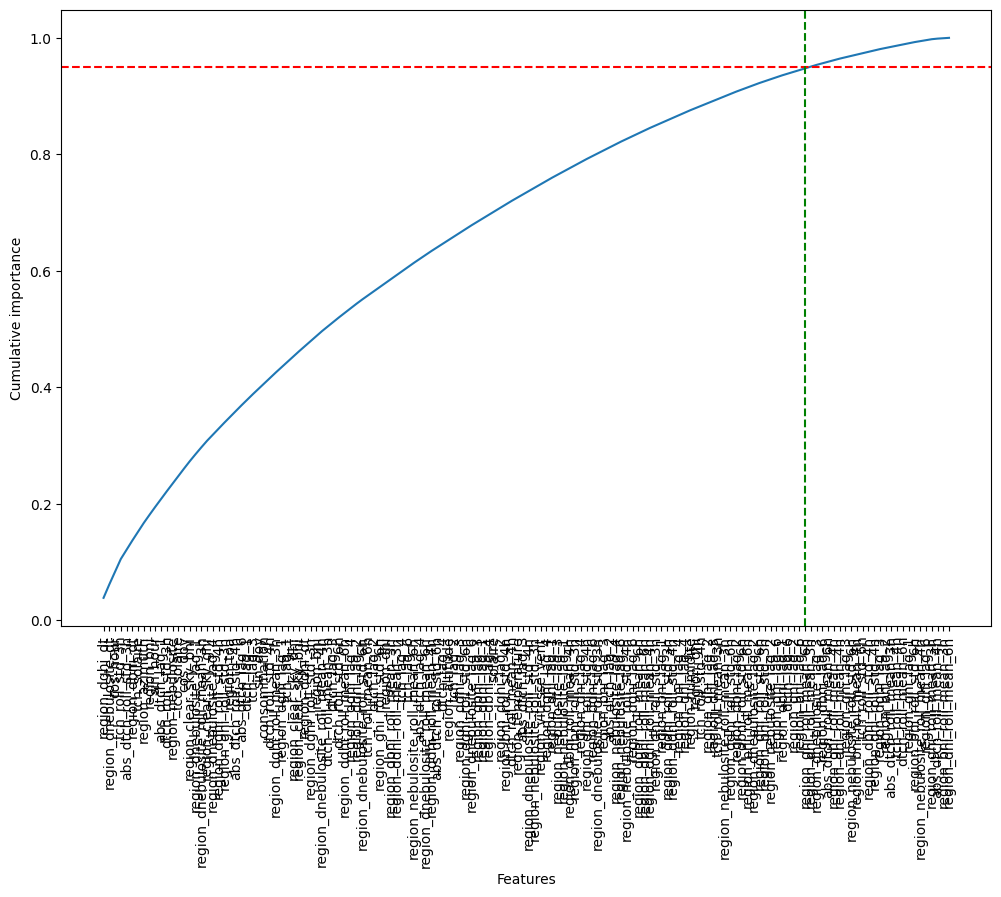

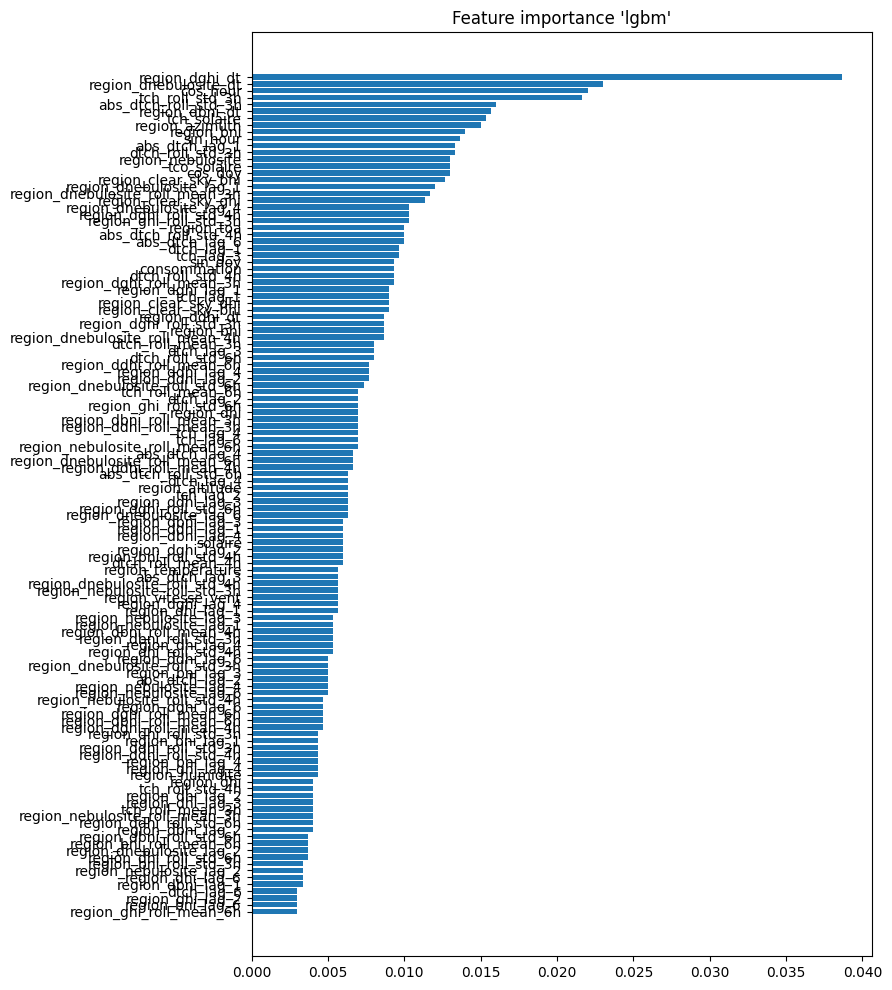

In [252]:
# Importance des variables sur TRAIN uniquement
importance_lgbm = variables_importantes(LGBMRegressor, X_train, y_train)

# Calcul de l'importance cumulée normalisée
cum_importance_lgbm = importance_lgbm.cumsum() / importance_lgbm.sum()

# Sélection des variables expliquant jusqu'à 95% de l'importance
selected_features_lgbm = cum_importance_lgbm[cum_importance_lgbm <= 0.95].index

# Identification de la variable correspondant approximativement au seuil
index_threshold = cum_importance_lgbm[cum_importance_lgbm.round(2) == 0.95].index[0]

# Visualisation de l'importance cumulée des variables
plt.figure(figsize=(12,8))
plt.plot(cum_importance_lgbm.index, cum_importance_lgbm)
plt.axhline(0.95, color='red', linestyle='--')
plt.axvline(index_threshold, color='green', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.show()

# Visualisation de l'importance des variables sélectionnées
plt.figure(figsize=(8,12))
plt.barh(selected_features_lgbm, importance_lgbm[selected_features_lgbm]/importance_lgbm.sum())
plt.gca().invert_yaxis()
plt.title("Feature importance 'lgbm'")
plt.show()


| Paramètre             | Explication                                                                                                                                                                                                        |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `n_estimators`        | Nombre d’arbres de boosting (itérations). Un plus grand nombre d’arbres améliore généralement les performances mais augmente le temps d’entraînement et le risque de surapprentissage (overfitting).               |
| `learning_rate`       | Taille du pas utilisée lors de la mise à jour des poids du modèle pendant le boosting. Des valeurs petites ralentissent l’apprentissage mais améliorent souvent la capacité de généralisation.                     |
| `num_leaves`          | Nombre maximal de feuilles par arbre. Des valeurs plus grandes permettent au modèle de capturer des relations plus complexes mais peuvent conduire au surapprentissage.                                            |
| `max_depth`           | Profondeur maximale de chaque arbre. `-1` signifie qu’il n’y a pas de limite. Limiter la profondeur aide à contrôler le surapprentissage et à réduire la complexité du modèle.                                     |
| `min_child_samples`   | Nombre minimum d’échantillons requis dans un nœud feuille. Des valeurs plus élevées rendent le modèle plus conservateur et réduisent le surapprentissage.                                                          |
| `subsample`           | Fraction des échantillons d’entraînement utilisée pour construire chaque arbre (échantillonnage des lignes). Des valeurs inférieures à 1 introduisent de l’aléatoire et améliorent la généralisation.              |
| `colsample_bytree`    | Fraction des variables (features) sélectionnées aléatoirement pour chaque arbre (échantillonnage des variables). Cela aide à réduire la corrélation entre les arbres et limite le surapprentissage.                |
| `reg_alpha`           | Terme de régularisation L1 appliqué aux poids des feuilles. Il favorise la parcimonie et réduit le surapprentissage en pénalisant les poids trop élevés.                                                           |
| `reg_lambda`          | Terme de régularisation L2 appliqué aux poids des feuilles. Il stabilise le modèle en pénalisant les coefficients trop grands et améliore la généralisation.                                                       |
| `estimator`           | Modèle d’apprentissage automatique à optimiser (ici c'est la régression LightGBM).                                                                                                                                              |
| `param_distributions` | Dictionnaire définissant l’espace de recherche des hyperparamètres.                                                                                                                                                |
| `n_iter`              | Nombre de combinaisons de paramètres testées aléatoirement. Des valeurs plus élevées explorent davantage de configurations mais augmentent le temps de calcul.                                                     |
| `scoring`             | Métrique d’évaluation utilisée pendant la validation croisée. `"neg_mean_absolute_error"` est utilisé car sklearn maximise les scores ; le signe négatif permet de transformer le MAE en problème de maximisation. |
| `cv`                  | Stratégie de validation croisée. Ici `TimeSeriesSplit` garantit que l’entraînement se fait sur des données passées et la validation sur des données futures.                                                       |
| `refit`               | Si `True`, le meilleur modèle trouvé pendant la validation croisée est réentraîné sur l’ensemble complet des données d’entraînement.                                                                               |


In [254]:
# Création d'une validation croisée adaptée aux séries temporelles (5 splits)
tscv = TimeSeriesSplit(n_splits=3)

# Initialisation du modèle LightGBM pour la régression
lgbm = LGBMRegressor(n_jobs=-1, random_state=42)

# Définition de l'espace de recherche des hyperparamètres
param_dist_lgbm = {
    "n_estimators": [300, 1000, 1500, 2000],
    "learning_rate": loguniform(0.005, 0.05),
    "max_depth": randint(3, 7),
    "num_leaves": randint(20, 60),
    "min_child_samples": randint(30, 120),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "reg_alpha": loguniform(1e-3, 10),
    "reg_lambda": loguniform(1e-2, 10),
}

# Recherche aléatoire des meilleurs hyperparamètres avec validation croisée
search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=300,   # 10 combinaisons testées, donc 100*5 = 500 fits
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# Entraînement de la recherche d'hyperparamètres sur TRAIN
search_lgbm.fit(X_train[selected_features_lgbm], y_train)

# Meilleur modèle après tuning
best_model = search_lgbm.best_estimator_

# Prédictions sur TRAIN et VALID
y_train_pred_lgbm = best_model.predict(X_train[selected_features_lgbm])
y_valid_pred_lgbm = best_model.predict(X_valid[selected_features_lgbm])

# Scores sur TRAIN et VALID
print("R² train :", r2_score(y_train, y_train_pred_lgbm))
print("R² valid :", r2_score(y_valid, y_valid_pred_lgbm))
print("MAE train :", mean_absolute_error(y_train, y_train_pred_lgbm))
print("MAE valid :", mean_absolute_error(y_valid, y_valid_pred_lgbm))

# Meilleurs hyperparamètres trouvés
print("Meilleurs paramètres LightGBM :")
print(search_lgbm.best_params_)

# Meilleur score CV (on remet le signe positif)
print("Meilleur score CV (MAE) :", -search_lgbm.best_score_)

# Sauvegarde du modèle de recherche
with open(filepath_output + "search_lgbm_pickle.pkl", "wb") as f:
    pickle.dump(search_lgbm, f)

# Rechargement si besoin
with open("search_lgbm_pickle.pkl", "rb") as f:
    search_lgbm = pickle.load(f)

Fitting 3 folds for each of 300 candidates, totalling 900 fits


KeyboardInterrupt: 

In [ ]:

# Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_valid_lgbm = pd.concat([X_train[selected_features_lgbm], X_valid[selected_features_lgbm]])
y_train_valid_lgbm = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_lgbm = X_test[selected_features_lgbm].copy()
y_test_lgbm = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params_lgbm = search_lgbm.best_params_
# params = best_params_lgbm.copy()
# params['max_depth'] = 9
# params['subsample'] = 0.8

# Initialisation du modèle LightGBM de régression
final_lgbm = LGBMRegressor(
    n_jobs=-1,
    random_state=42,
    bagging_freq=1,
    **best_params_lgbm
)

# Entraînement du modèle
final_lgbm.fit(X_train_valid_lgbm, y_train_valid_lgbm)

# Prédiction sur le jeu de test/train
y_pred_lgbm = final_lgbm.predict(X_test_lgbm)
y_pred_train_valid_lgbm = final_lgbm.predict(X_train_valid_lgbm)

# Évaluation
mae_lgbm = mean_absolute_error(y_test_lgbm, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_lgbm, y_pred_lgbm))
r2_test_lgbm = r2_score(y_test_lgbm, y_pred_lgbm)
r2_train_valid_lgbm = r2_score(y_train_valid_lgbm, y_pred_train_valid_lgbm)
mae_rel_lgbm = mae_lgbm / y_test_lgbm.mean() * 100

print("\n--- Résultats LGBM ---")
print("MAE               :", mae_lgbm)
print(f"MAE relatif      : {round(mae_rel_lgbm, 3)}%")
print("RMSE              :", rmse_lgbm)
print("R² train_valid    :", r2_train_valid_lgbm)
print("R² test           :", r2_test_lgbm)


[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25572
[LightGBM] [Info] Number of data points in the train set: 87649, number of used features: 103
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_lgbm, y_pred_lgbm, alpha=0.5)
plt.plot([y_test_lgbm.min(), y_test_lgbm.max()],
         [y_test_lgbm.min(), y_test_lgbm.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
# plt.xlim(-20,20)
# plt.ylim(-20,20)
plt.title("LGBM - Réel vs Prédit")
plt.show()

TRAIN target mean : -8.111064124656306e-19
TRAIN target std  : 4.055604612253081
VALID target mean : -2.4300367160058146e-18
VALID target std  : 4.176018389825006
TEST target mean  : 0.0012956075987536418
TEST target std   : 4.0349340026637295


In [ ]:
print("TRAIN ghi mean :", X_train["region_ghi"].mean())
print("TRAIN ghi std  :", X_train["region_ghi"].std())

print("VALID ghi mean :", X_valid["region_ghi"].mean())
print("VALID ghi std  :", X_valid["region_ghi"].std())

print("TEST ghi mean  :", X_test["region_ghi"].mean())
print("TEST ghi std   :", X_test["region_ghi"].std())

TRAIN ghi mean : 94.10934250651623
TRAIN ghi std  : 134.24930001040298
VALID ghi mean : 93.66758586935704
VALID ghi std  : 133.04225180941637
TEST ghi mean  : 86.49054796748416
TEST ghi std   : 129.04570029920777



# Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_lgbm = X_train[selected_features_lgbm]
y_train_lgbm = y_train

X_valid_lgbm = X_valid[selected_features_lgbm]
y_valid_lgbm = y_valid

# Construction du jeu de test
X_test_lgbm = X_test.loc[: "2025-12-31 23:30:00+00:00", selected_features_lgbm].copy()
y_test_lgbm = y_test.loc[: "2025-12-31 23:30:00+00:00"].copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params_lgbm = search_lgbm.best_params_
params = best_params_lgbm.copy()
params = {
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'reg_lambda': 10.0,
    'reg_alpha': 5.0,
    'num_leaves': 15,
    'n_estimators': 300,
    'min_child_samples': 100,
    'max_depth': 4,
    'learning_rate': 0.03
}

# Initialisation du modèle LightGBM de régression
final_lgbm = LGBMRegressor(
    n_jobs=-1,  
    random_state=42,
    # bagging_freq=1,
    **params
)

# Entraînement du modèle
final_lgbm.fit(X_train_lgbm, y_train_lgbm)

# Prédiction sur le jeu de test/train
y_pred_lgbm = final_lgbm.predict(X_test_lgbm)
y_pred_train_lgbm = final_lgbm.predict(X_train_lgbm)
y_pred_valid_lgbm = final_lgbm.predict(X_valid_lgbm)


# Évaluation
mae_lgbm = mean_absolute_error(y_test_lgbm, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_lgbm, y_pred_lgbm))
r2_train_lgbm = r2_score(y_train_lgbm, y_pred_train_lgbm)
r2_valid_lgbm = r2_score(y_valid_lgbm, y_pred_valid_lgbm)
r2_test_lgbm = r2_score(y_test_lgbm, y_pred_lgbm)
mae_rel_lgbm = mae_lgbm / y_test_lgbm.mean() * 100

print("\n--- Résultats LGBM ---")
print("MAE         :", mae_lgbm)
print(f"MAE relatif : {round(mae_rel_lgbm, 3)}%")
print("RMSE        :", rmse_lgbm)
print("R² train    :", r2_train_lgbm)
print("R² valid    :", r2_valid_lgbm)
print("R² test     :", r2_test_lgbm)


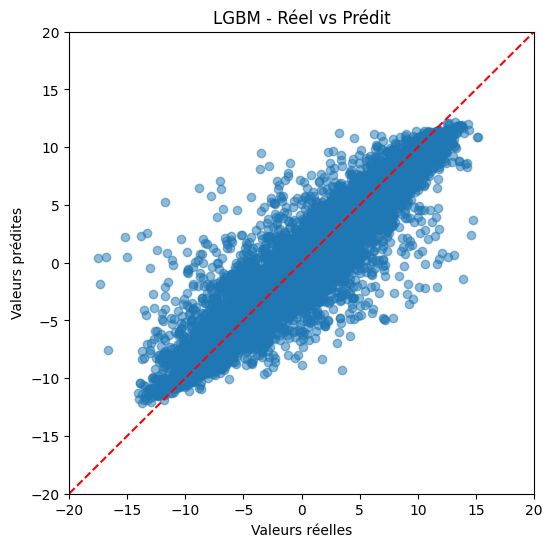

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_lgbm, y_pred_lgbm, alpha=0.5)
plt.plot([y_test_lgbm.min(), y_test_lgbm.max()],
         [y_test_lgbm.min(), y_test_lgbm.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.title("LGBM - Réel vs Prédit")
plt.show()

In [ ]:
best_params_lgbm

{'subsample': 0.9,
 'reg_lambda': 5.0,
 'reg_alpha': 1.0,
 'num_leaves': 127,
 'n_estimators': 1000,
 'min_child_samples': 50,
 'max_depth': 10,
 'learning_rate': 0.02,
 'colsample_bytree': 0.8}

## XGBRegressor

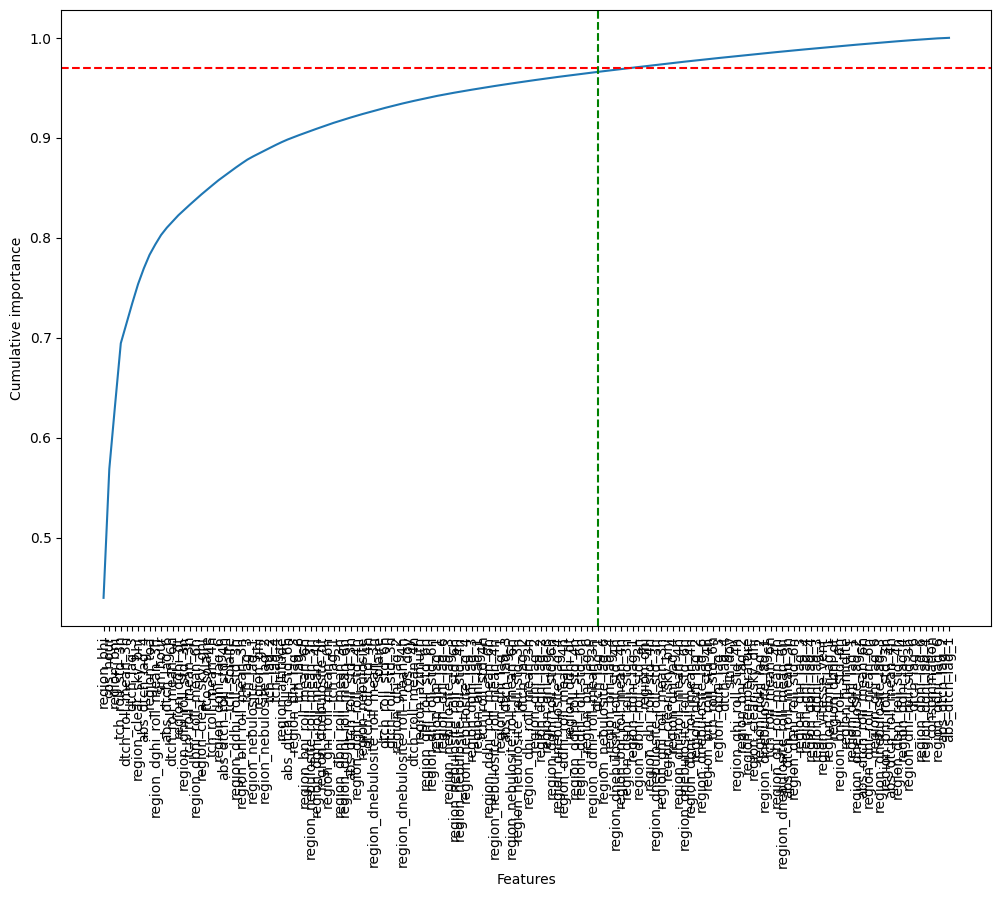

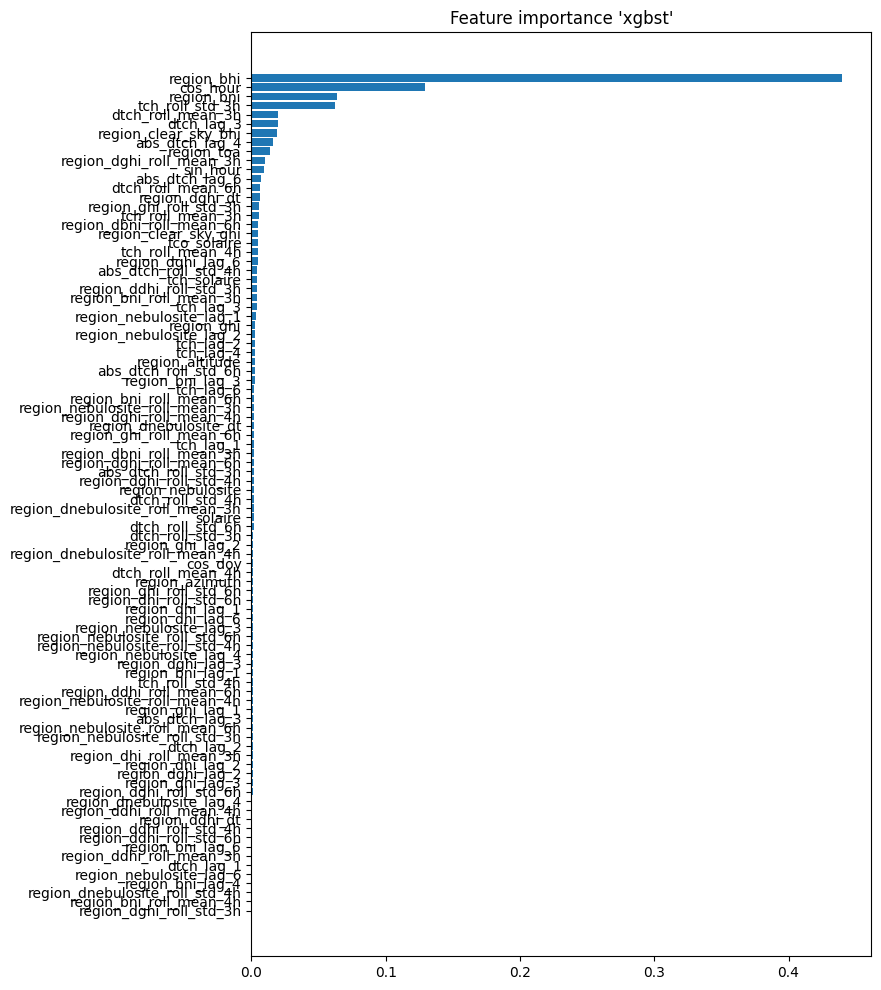

In [217]:
# Calcul et tri de l'importance des variables
importance_xgb = variables_importantes(XGBRegressor, X_train, y_train).sort_values(ascending=False)
threshold = 0.97

# Calcul de l'importance cumulée normalisée
cum_importance_xgb = importance_xgb.cumsum() / importance_xgb.sum()

# Sélection des variables expliquant jusqu'à 95% de l'importance
selected_features_xgb = cum_importance_xgb[cum_importance_xgb <= threshold].index

# Identification de la variable correspondant approximativement au seuil
index_threshold = cum_importance_xgb[cum_importance_xgb.round(2) == threshold].index[1]

# Visualisation de l'importance cumulée des variables
plt.figure(figsize=(12,8))
plt.plot(cum_importance_xgb.index, cum_importance_xgb)
plt.axhline(threshold, color='red', linestyle='--')
plt.axvline(index_threshold, color='green', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.show()

# Visualisation de l'importance des variables sélectionnées
plt.figure(figsize=(8,12))
plt.barh(selected_features_xgb, importance_xgb[selected_features_xgb]/importance_xgb.sum())
plt.gca().invert_yaxis()
plt.title("Feature importance 'xgbst'")
plt.show()

| Paramètre             | Explication                                                                                                                                                                           |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `n_estimators`        | Nombre d’arbres de boosting construits successivement. Une grande valeur peut améliorer les performances, mais augmente le temps de calcul et le risque de surapprentissage.          |
| `learning_rate`       | Taux d’apprentissage appliqué à la contribution de chaque arbre. Une petite valeur rend l’apprentissage plus progressif, mais nécessite souvent plus d’arbres.                        |
| `max_depth`           | Profondeur maximale de chaque arbre. Des arbres plus profonds capturent des relations plus complexes, mais peuvent surajuster les données.                                            |
| `min_child_weight`    | Poids minimal requis dans un nœud feuille pour autoriser une nouvelle division. Une valeur élevée rend le modèle plus conservateur.                                                   |
| `subsample`           | Fraction des observations d’entraînement utilisée pour construire chaque arbre. Une valeur inférieure à 1 peut aider à réduire le surapprentissage.                                   |
| `colsample_bytree`    | Fraction des variables utilisée pour construire chaque arbre. Cela permet de diversifier les arbres et de limiter le surapprentissage.                                                |
| `gamma`               | Gain minimal requis pour effectuer une nouvelle division dans un arbre. Plus `gamma` est grand, plus le modèle devient prudent dans les divisions.                                    |
| `reg_alpha`           | Régularisation L1 appliquée aux poids du modèle. Elle peut forcer certains poids à devenir nuls et ainsi rendre le modèle plus parcimonieux.                                          |
| `reg_lambda`          | Régularisation L2 appliquée aux poids du modèle. Elle pénalise les poids trop grands et aide à stabiliser le modèle.                                                                  |
| `tree_method`         | Méthode de construction des arbres. Ici `hist` utilise un algorithme basé sur des histogrammes, souvent plus rapide et efficace sur de grands jeux de données.                        |
| `max_bin`             | Nombre maximal d’intervalles utilisés pour discrétiser les variables continues avec `tree_method="hist"`. Une valeur plus grande peut améliorer la précision mais ralentir le calcul. |
| `n_iter`              | Nombre de combinaisons de paramètres testées aléatoirement parmi tout l’espace possible.                                                                                              |
| `scoring`             | Métrique utilisée pour comparer les modèles pendant la validation croisée. Ici `neg_mean_absolute_error` correspond à la MAE négative.                                                |
| `cv`                  | Méthode de validation croisée utilisée, ici `TimeSeriesSplit`, adaptée aux séries temporelles.                                                                                        |
| `refit`               | Si `True`, le meilleur modèle trouvé est réentraîné automatiquement sur toutes les données d’entraînement après la recherche.                                                         |


In [218]:
# Validation croisée adaptée aux séries temporelles
tscv = TimeSeriesSplit(n_splits=3)

# Initialisation du modèle XGBoost
xgb = XGBRegressor(
    n_jobs=-1,
    random_state=42
)

# Espace de recherche des hyperparamètres
param_dist_xgb = {
    "n_estimators": [1000, 2000, 2500],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "max_depth": [4, 7, 10, 13],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0.01, 0.1, 1.0],
    "reg_lambda": [0.01, 0.1, 1.0, 5.0],
    # "tree_method": ["hist"],
    # "max_bin": [256, 512]
}

# Recherche aléatoire des hyperparamètres
search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=300,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# Entraînement
search_xgb.fit(X_train[selected_features_xgb], y_train)

# Meilleurs paramètres
print("Meilleurs paramètres XGBoost :")
print(search_xgb.best_params_)

# Meilleur score
print("Meilleur score CV (MAE) :", -search_xgb.best_score_)

# Sauvegarde de l'objet search_xgb dans un fichier pickle
with open('search_xgb_pickle.pkl', 'wb') as f:
    pickle.dump(search_xgb, f)

# Chargement de l'objet search_xgb depuis le fichier pickle
with open('search_xgb_pickle.pkl', 'rb') as f:
    search_xgb = pickle.load(f)

Fitting 3 folds for each of 300 candidates, totalling 900 fits
Meilleurs paramètres XGBoost :
{'subsample': 0.8, 'reg_lambda': 0.01, 'reg_alpha': 0.01, 'n_estimators': 2500, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
Meilleur score CV (MAE) : 0.4314629622507881



--- Résultats ExtraTreesRegressor ---
MAE test             : 0.47593616241317915
MAE train_valid      : 0.10073198401833514
NMAE test            : 19.776 %
NMAE train_valid     : 4.126 %
RMSE test            : 1.0981259179325529
RMSE train_valid     : 0.18848490083542072
R² test              : 0.8880829873687082
R² train_valid       : 0.9742752102445998


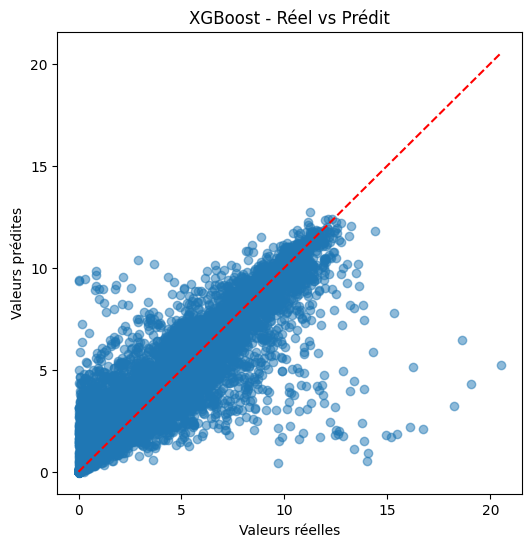

In [275]:

# Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_xgb = pd.concat([X_train[selected_features_xgb], X_valid[selected_features_xgb]])
y_train_xgb = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_xgb = X_test[selected_features_xgb].copy()
y_test_xgb = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params = search_xgb.best_params_

# Initialisation du modèle XGBoost de régression
final_xgb = XGBRegressor(
    eval_metric="mae",
    n_jobs=-1,
    random_state=42,
    **best_params
)

# Entraînement du modèle
final_xgb.fit(X_train_xgb, y_train_xgb)

# Prédiction sur le jeu de test/train
y_pred_xgb = final_xgb.predict(X_test_xgb)
y_pred_train_xgb = final_xgb.predict(X_train_xgb)

# Évaluation
mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)
mae_train_xgb = mean_absolute_error(y_train_xgb, y_pred_train_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
rmse_train_xgb = np.sqrt(mean_squared_error(y_train_xgb, y_pred_train_xgb))
r2_test_xgb = r2_score(y_test_xgb, y_pred_xgb)
r2_train_xgb = r2_score(y_train_xgb, y_pred_train_xgb)
nmae_xgb = round(mae_xgb / y_test_xgb.mean() * 100, 3)
nmae_train_xgb = round(mae_train_xgb / y_train_xgb.mean() * 100, 3)

print("\n--- Résultats ExtraTreesRegressor ---")
print(f"MAE test             : {mae_xgb}")
print(f"MAE train_valid      : {mae_train_xgb}")
print(f"NMAE test            : {nmae_xgb} %")
print(f"NMAE train_valid     : {nmae_train_xgb} %")
print(f"RMSE test            : {rmse_xgb}")
print(f"RMSE train_valid     : {rmse_train_xgb}")
print(f"R² test              : {r2_test_xgb}")
print(f"R² train_valid       : {r2_train_etr}")

plt.figure(figsize=(6,6))
plt.scatter(y_test_xgb, y_pred_xgb, alpha=0.5)
plt.plot([y_test_xgb.min(), y_test_xgb.max()],
         [y_test_xgb.min(), y_test_xgb.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("XGBoost - Réel vs Prédit")
plt.show()

# ExtraTreesRegressor

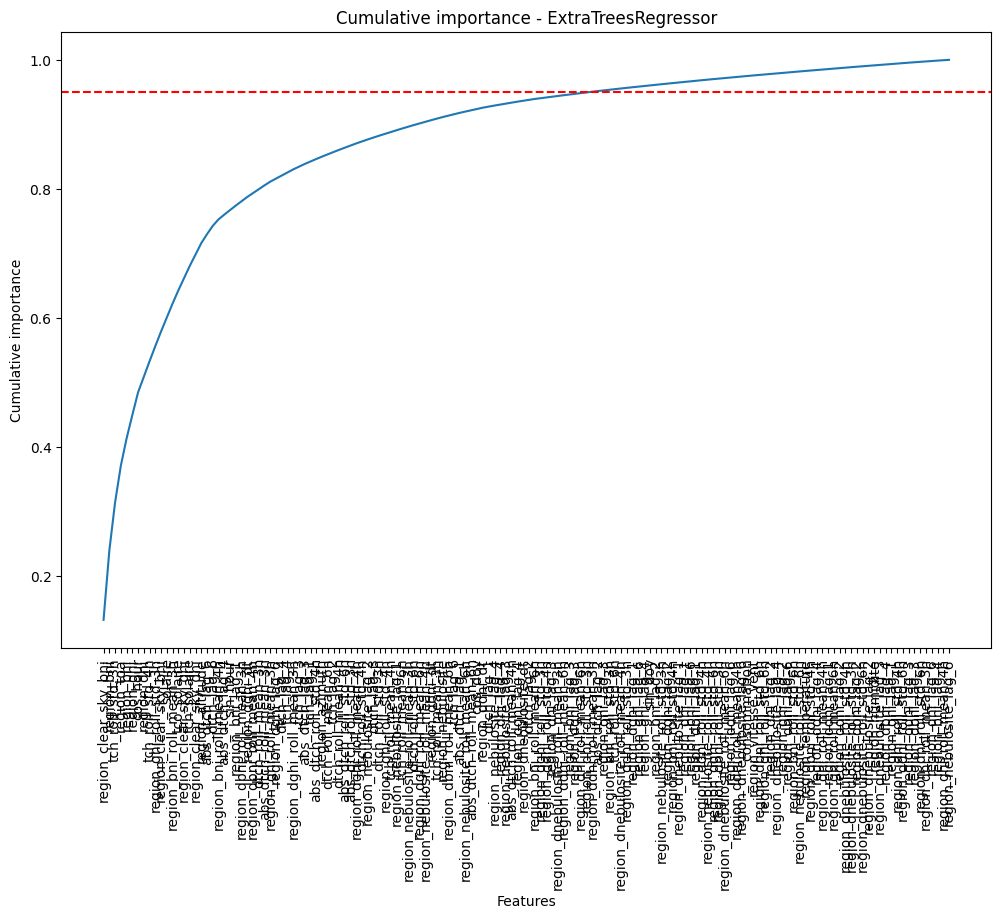

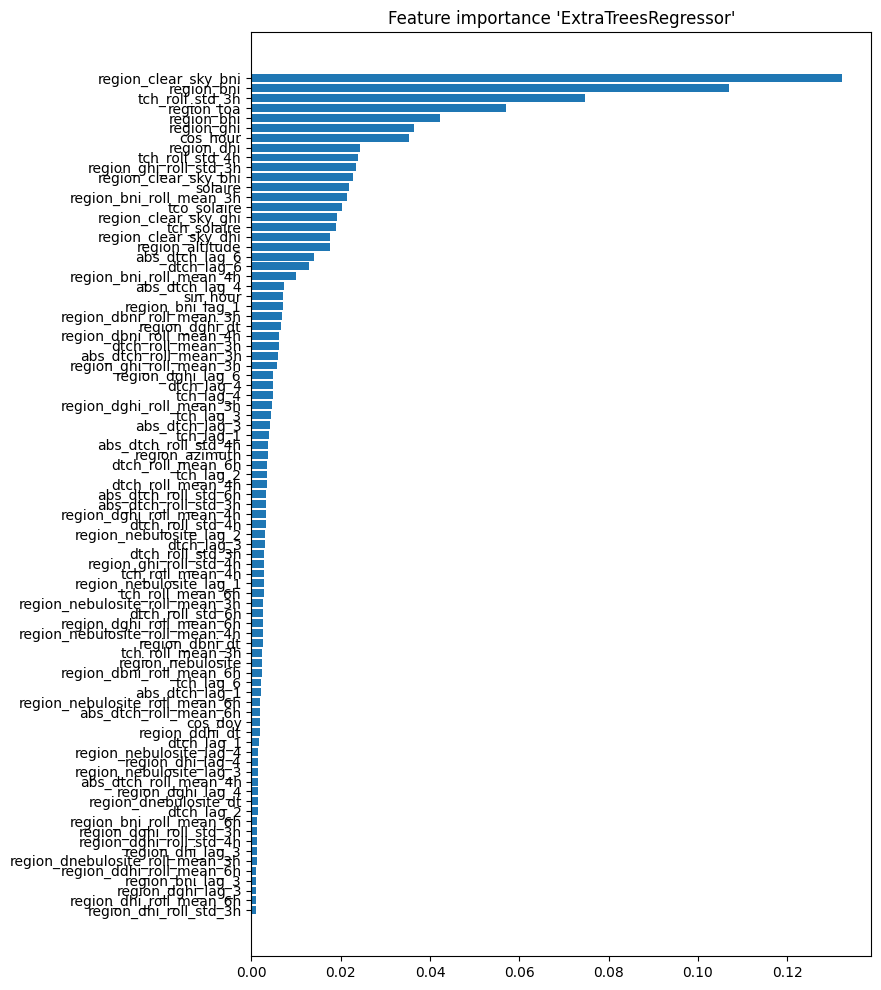

In [201]:
importance_etr = variables_importantes(ExtraTreesRegressor, X_train, y_train)

importance_etr = importance_etr.sort_values(ascending=False)

cum_importance_etr = importance_etr.cumsum() / importance_etr.sum()

selected_features_etr = cum_importance_etr[cum_importance_etr <= 0.95].index

plt.figure(figsize=(12,8))
plt.plot(cum_importance_etr.index, cum_importance_etr)
plt.axhline(0.95, color='red', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.title("Cumulative importance - ExtraTreesRegressor")
plt.show()

plt.figure(figsize=(8,12))
plt.barh(selected_features_etr, importance_etr[selected_features_etr] / importance_etr.sum())
plt.gca().invert_yaxis()
plt.title("Feature importance 'ExtraTreesRegressor'")
plt.show()

In [212]:
# Création d'une validation croisée adaptée aux séries temporelles
tscv = TimeSeriesSplit(n_splits=5)

# Initialisation du modèle ExtraTreesRegressor
etr = ExtraTreesRegressor(random_state=42, n_jobs=-1)

# Définition de l'espace de recherche des hyperparamètres
param_dist_etr = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [6, 8, 10, 12, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0]
}

# Recherche aléatoire des meilleurs hyperparamètres
search_etr = RandomizedSearchCV(
    estimator=etr,
    param_distributions=param_dist_etr,
    n_iter=150,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# Entraînement
search_etr.fit(X_valid[selected_features_etr], y_valid)

# Affichage des meilleurs paramètres trouvés
print("Meilleurs paramètres ExtraTreesRegressor :")
print(search_etr.best_params_)

# Affichage du meilleur score MAE
print("Meilleur score CV (MAE) :", -search_etr.best_score_)

with open("search_etr_pickle.pkl", mode="bw") as f:
    pickle.dump(search_etr, f)

with open("search_etr_pickle.pkl", "rb") as f:
    search_etr = pickle.load(f)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Meilleurs paramètres ExtraTreesRegressor :
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15}
Meilleur score CV (MAE) : 0.5535957023461678


In [274]:

# # Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_etr = pd.concat([X_train[selected_features_etr], X_valid[selected_features_etr]])
y_train_etr = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_etr = X_test[selected_features_etr].copy()
y_test_etr = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params_etr = search_etr.best_params_

# Initialisation du modèle Extra Trees de régression
final_etr = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params_etr
)

# Entraînement du modèle
final_etr.fit(X_train_etr, y_train_etr)

# Prédiction sur le jeu de test/train
y_pred_etr = final_etr.predict(X_test_etr)
y_pred_train_etr = final_etr.predict(X_train_etr)

# Évaluation
mae_etr = mean_absolute_error(y_test_etr, y_pred_etr)
mae_train_etr = mean_absolute_error(y_train_etr, y_pred_train_etr)
rmse_etr = np.sqrt(mean_squared_error(y_test_etr, y_pred_etr))
rmse_train_etr = np.sqrt(mean_squared_error(y_train_etr, y_pred_train_etr))
r2_test_etr = r2_score(y_test_etr, y_pred_etr)
r2_train_etr = r2_score(y_train_etr, y_pred_train_etr)
nmae_etr = round(mae_etr / y_test_etr.mean() * 100, 3)
nmae_train_etr = round(mae_train_etr / y_train_etr.mean() * 100, 3)

print("\n--- Résultats ExtraTreesRegressor ---")
print(f"MAE test             : {mae_etr}")
print(f"MAE train_valid      : {mae_train_etr}")
print(f"NMAE test            : {nmae_etr} %")
print(f"NMAE train_valid     : {nmae_train_etr} %")
print(f"RMSE test            : {rmse_etr}")
print(f"RMSE train_valid     : {rmse_train_etr}")
print(f"R² test              : {r2_test_etr}")
print(f"R² train_valid       : {r2_train_etr}")



--- Résultats ExtraTreesRegressor ---
MAE test             : 0.48952205300574764
MAE train_valid      : 0.25584874483046693
NMAE test            : 20.34 %
NMAE train_valid     : 10.479 %
RMSE test            : 1.1120204496539963
RMSE train_valid     : 0.5308602875791275
R² test              : 0.8852329091710034
R² train_valid       : 0.9742752102445998


In [266]:
def relative_mae_safe(y_true, y_pred, epsilon=1e-2):
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon)))

print(relative_mae_safe(y_test_etr, y_pred_etr))
print(relative_mae_safe(y_train_etr, y_pred_train_etr))


0.7812111844639291
0.4594017113596655


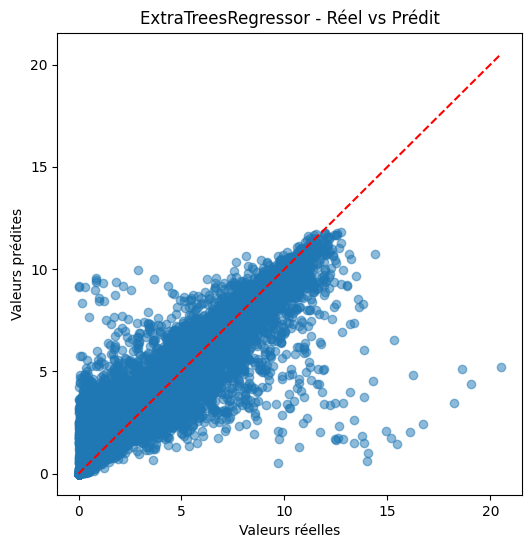

In [261]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_etr, y_pred_etr, alpha=0.5)
plt.plot([y_test_etr.min(), y_test_etr.max()],
         [y_test_etr.min(), y_test_etr.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("ExtraTreesRegressor - Réel vs Prédit")
plt.show()

In [34]:

# # Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_etr = pd.concat([X_train[selected_features_etr], X_valid[selected_features_etr]])
y_train_etr = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_etr = X_test[selected_features_etr].copy()
y_test_etr = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
# best_params_etr = search_etr.best_params_

# Initialisation du modèle Extra Trees de régression
final_etr = ExtraTreesRegressor(max_depth=9, n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    # **best_params_etr
)

# Entraînement du modèle
final_etr.fit(X_train, y_train)

# Prédiction sur le jeu de test/train
y_pred_etr = final_etr.predict(X_valid)
y_pred_train_etr = final_etr.predict(X_train)

# Évaluation
mae_etr = mean_absolute_error(y_valid, y_pred_etr)
rmse_etr = np.sqrt(mean_squared_error(y_valid, y_pred_etr))
r2_test_etr = r2_score(y_valid, y_pred_etr)
r2_train_etr = r2_score(y_train, y_pred_train_etr)
mae_rel_etr = mae_etr / y_valid.mean() * 100

print("\n--- Résultats ExtraTreesRegressor ---")
print("MAE         :", mae_etr)
print(f"MAE relatif : {round(mae_rel_etr, 3)}%")
print("RMSE        :", rmse_etr)
print("R² train    :", r2_train_etr)
print("R² test     :", r2_test_etr)



--- Résultats ExtraTreesRegressor ---
MAE         : 0.531194249972001
MAE relatif : 21.409%
RMSE        : 1.1088835361653548
R² train    : 0.9236083156371238
R² test     : 0.8910500854599026


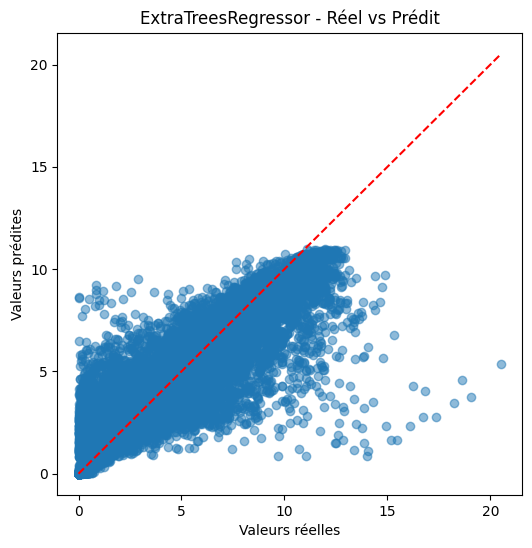

In [35]:
plt.figure(figsize=(6,6))
plt.scatter(y_valid, y_pred_etr, alpha=0.5)
plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("ExtraTreesRegressor - Réel vs Prédit")
plt.show()

## # Enlever les nuits

In [132]:
train_jour = train.copy() # entrainement 2020-2023
valid_jour = valid.copy() #2024 cas1 test 2024
test_jour = test.copy() # cas 2 test sur 2025

# train_jour['is_night'] = (train_jour["region_ghi"] <= 5).astype(int)
# valid_jour['is_night'] = (valid_jour["region_ghi"] <= 5).astype(int)
# test_jour['is_night'] = (test_jour["region_ghi"] <= 5).astype(int)

X_train_jour = train_jour .drop(['target'], axis=1)
y_train_jour = train_jour ["target"]

# X_valid = valid.drop(['target'], axis=1)
X_valid_jour = valid_jour .drop(['target'], axis=1)
y_valid_jour = valid_jour ["target"]

# X_test = test.drop(['target'], axis=1)
X_test_jour = test_jour .drop(['target'], axis=1)
y_test_jour = test_jour ["target"]

# # Enlever les nuits
with open("search_etr_pickle.pkl", "rb") as f:
    search_etr = pickle.load(f)


# Initialisation du modèle Extra Trees de régression
final_etr_jour = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1,
    n_estimators= 1000,
    min_samples_split= 2, 
    min_samples_leaf= 8, 
    max_features= 1.0, 
    max_depth= 12,
)

# Entraînement du modèle
final_etr_jour.fit(X_train_jour , y_train_jour )

# Prédiction sur le jeu de test/train
y_pred_etr_jour = final_etr_jour.predict(X_valid_jour )
y_pred_train_etr_jour = final_etr_jour.predict(X_train_jour )

# Évaluation
mae_etr_jour = mean_absolute_error(y_valid_jour, y_pred_etr_jour)
rmse_etr_jour = np.sqrt(mean_squared_error(y_valid_jour, y_pred_etr_jour))
r2_test_etr_jour = r2_score(y_valid_jour, y_pred_etr_jour)
r2_train_etr_jour = r2_score(y_train_jour, y_pred_train_etr_jour)
mae_rel_etr_jour = mae_etr_jour / y_valid_jour.mean() * 100

print("\n--- Résultats ExtraTreesRegressor ---")
print("MAE         :", mae_etr_jour)
print(f"MAE relatif : {round(mae_rel_etr_jour, 3)}%")
print("RMSE        :", rmse_etr_jour)
print("R² train    :", r2_train_etr_jour)
print("R² test     :", r2_test_etr_jour)



--- Résultats ExtraTreesRegressor ---
MAE         : 0.4987547273705502
MAE relatif : 20.101%
RMSE        : 1.0769884273397528
R² train    : 0.9442001531346951
R² test     : 0.8972274585381822


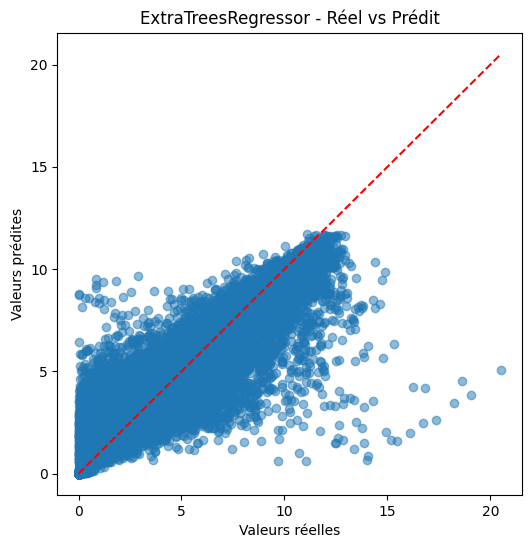

In [133]:
plt.figure(figsize=(6,6))
plt.scatter(y_valid_jour, y_pred_etr_jour, alpha=0.5)
plt.plot([y_valid_jour.min(), y_valid_jour.max()],
         [y_valid_jour.min(), y_valid_jour.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("ExtraTreesRegressor - Réel vs Prédit")
plt.show()

In [207]:
test.loc[test.target > 15, ['region_ghi', 'tch_solaire','target']]

,region_ghi,tch_solaire,target
datetime_utc,,,
2024-03-18 09:30:00+00:00,230.71,43.72,15.30
2024-04-05 11:30:00+00:00,412.75,74.32,15.47
2024-04-12 10:30:00+00:00,414.13,74.24,15.17
2024-04-16 09:00:00+00:00,350.27,47.65,19.05
2024-04-20 12:30:00+00:00,444.12,81.08,16.08
2024-05-18 09:30:00+00:00,396.90,64.82,16.74
2024-06-10 13:30:00+00:00,411.99,74.85,18.22
2024-06-19 09:30:00+00:00,243.26,37.01,16.22
2024-06-19 13:00:00+00:00,242.83,41.72,18.62


In [211]:
test.loc['2024-06-19',['region_ghi', 'tch_solaire', 'target']]

,region_ghi,tch_solaire,target
datetime_utc,,,
2024-06-19 00:00:00+00:00,0.00,0.00,0.00
2024-06-19 00:30:00+00:00,0.00,0.00,0.00
2024-06-19 01:00:00+00:00,0.00,0.00,0.00
2024-06-19 01:30:00+00:00,0.00,0.00,0.00
2024-06-19 02:00:00+00:00,0.00,0.00,0.00
2024-06-19 02:30:00+00:00,0.00,0.00,0.00
2024-06-19 03:00:00+00:00,0.00,0.00,0.00
2024-06-19 03:30:00+00:00,0.00,0.00,0.04
2024-06-19 04:00:00+00:00,1.50,0.04,1.27


In [134]:
train_jour = train.copy()
valid_jour = valid.copy()
test_jour = test.copy()

# train_jour['is_night'] = (train_jour["region_ghi"] <= 5).astype(int)
# valid_jour['is_night'] = (valid_jour["region_ghi"] <= 5).astype(int)
# test_jour['is_night'] = (test_jour["region_ghi"] <= 5).astype(int)

X_train_jour = train_jour .drop(['target'], axis=1)
y_train_jour = train_jour ["target"]

# X_valid = valid.drop(['target'], axis=1)
X_valid_jour = valid_jour .drop(['target'], axis=1)
y_valid_jour = valid_jour ["target"]

# X_test = test.drop(['target'], axis=1)
X_test_jour = test_jour .drop(['target'], axis=1)
y_test_jour = test_jour ["target"]

# # Enlever les nuits
with open("search_etr_pickle.pkl", "rb") as f:
    search_etr = pickle.load(f)


# Initialisation du modèle Extra Trees de régression
final_etr_jour = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1,
    n_estimators= 1000,
    min_samples_split= 2, 
    min_samples_leaf= 8, 
    max_features= 1.0, 
    max_depth= 12,
)

# Entraînement du modèle
final_etr_jour.fit(X_train_jour , y_train_jour )

# Prédiction sur le jeu de test/train
y_pred_etr_jour = final_etr_jour .predict(X_test_jour )
y_pred_train_etr_jour = final_etr_jour.predict(X_train_jour )

# Évaluation
mae_etr_jour = mean_absolute_error(y_test_jour, y_pred_etr_jour)
rmse_etr_jour = np.sqrt(mean_squared_error(y_test_jour, y_pred_etr_jour))
r2_test_etr_jour = r2_score(y_test_jour, y_pred_etr_jour)
r2_train_etr_jour = r2_score(y_train_jour, y_pred_train_etr_jour)
mae_rel_etr_jour = mae_etr_jour / y_test_jour.mean() * 100

print("\n--- Résultats ExtraTreesRegressor ---")
print("MAE         :", mae_etr_jour)
print(f"MAE relatif : {round(mae_rel_etr_jour, 3)}%")
print("RMSE        :", rmse_etr_jour)
print("R² train    :", r2_train_etr_jour)
print("R² test     :", r2_test_etr_jour)



--- Résultats ExtraTreesRegressor ---
MAE         : 0.7833138923630352
MAE relatif : 33.373%
RMSE        : 1.473253561412187
R² train    : 0.9442001531346951
R² test     : 0.798589833157749


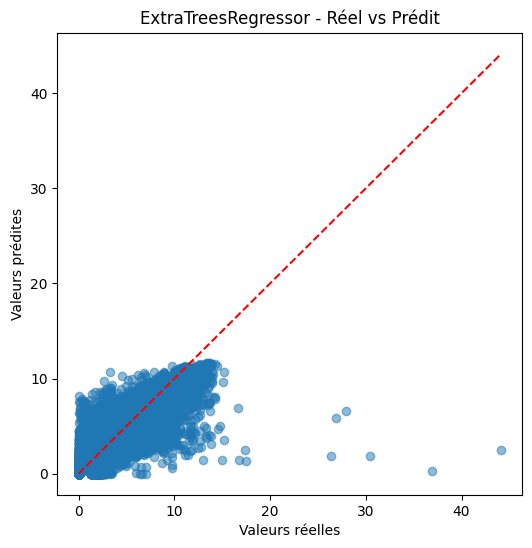

In [135]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_jour, y_pred_etr_jour, alpha=0.5)
plt.plot([y_test_jour.min(), y_test_jour.max()],
         [y_test_jour.min(), y_test_jour.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("ExtraTreesRegressor - Réel vs Prédit")
plt.show()

In [139]:

y_train_jour.describe(), y_valid_jour.describe(), y_test_jour.describe(), 

(count   52602.00
 mean        2.40
 std         3.27
 min         0.00
 25%         0.00
 50%         0.29
 75%         4.32
 max        24.97
 Name: target, dtype: float64,
 count   35080.00
 mean        2.48
 std         3.36
 min         0.00
 25%         0.00
 50%         0.31
 75%         4.47
 max        20.53
 Name: target, dtype: float64,
 count   19891.00
 mean        2.35
 std         3.28
 min         0.00
 25%         0.00
 50%         0.53
 75%         3.87
 max        44.15
 Name: target, dtype: float64)

In [160]:
test.loc[test.target > 25, ['region_ghi', 'target']]

,region_ghi,target
datetime_utc,,
2025-01-31 11:30:00+00:00,164.47,26.38
2025-03-30 12:30:00+00:00,408.88,30.47
2025-03-30 13:00:00+00:00,392.99,26.94
2025-08-18 16:30:00+00:00,135.59,27.96
2025-10-25 12:00:00+00:00,226.65,44.15
2025-10-25 13:00:00+00:00,0.00,36.88


<Axes: xlabel='datetime_utc'>

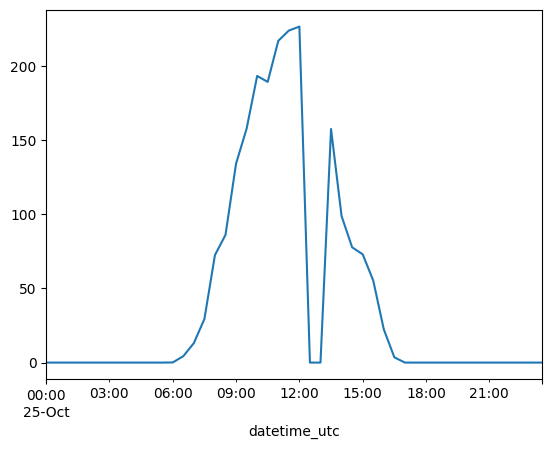

In [152]:
test.loc['2025-10-25', 'region_ghi'].plot()

In [159]:
test.loc['2025-08-18', ['region_ghi', 'target', 'tch_solaire']]

,region_ghi,target,tch_solaire
datetime_utc,,,
2025-08-18 00:00:00+00:00,0.00,0.00,0.00
2025-08-18 00:30:00+00:00,0.00,0.00,0.00
2025-08-18 01:00:00+00:00,0.00,0.00,0.00
2025-08-18 01:30:00+00:00,0.00,0.00,0.00
2025-08-18 02:00:00+00:00,0.00,0.00,0.00
2025-08-18 02:30:00+00:00,0.00,0.00,0.00
2025-08-18 03:00:00+00:00,0.00,0.00,0.00
2025-08-18 03:30:00+00:00,0.00,2.20,0.00
2025-08-18 04:00:00+00:00,0.00,0.11,2.20


In [192]:
valid.loc[((valid.index.hour>7) & (valid.index.hour<16) & (valid.region_ghi == 0)),
    ['region_altitude', 'region_azimuth', 'region_bhi', 'region_bni', 'tch_solaire']]

,region_altitude,region_azimuth,region_bhi,region_bni,tch_solaire
datetime_utc,,,,,


In [29]:

# # Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_etr = pd.concat([X_train[selected_features_etr], X_valid[selected_features_etr]])
y_train_etr = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_etr = X_test[selected_features_etr].copy()
y_test_etr = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
# best_params_etr = search_etr.best_params_

# Initialisation du modèle Extra Trees de régression
final_etr = ExtraTreesRegressor(max_depth=9, n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    # **best_params_etr
)

# Entraînement du modèle
final_etr.fit(X_train, y_train)

# Prédiction sur le jeu de test/train
y_pred_etr = final_etr.predict(X_test)
y_pred_train_etr = final_etr.predict(X_train)

# Évaluation
mae_etr = mean_absolute_error(y_test, y_pred_etr)
rmse_etr = np.sqrt(mean_squared_error(y_test, y_pred_etr))
r2_test_etr = r2_score(y_test, y_pred_etr)
r2_train_etr = r2_score(y_train, y_pred_train_etr)
mae_rel_etr = mae_etr / y_test.mean() * 100

print("\n--- Résultats ExtraTreesRegressor ---")
print("MAE         :", mae_etr)
print(f"MAE relatif : {round(mae_rel_etr, 3)}%")
print("RMSE        :", rmse_etr)
print("R² train    :", r2_train_etr)
print("R² test     :", r2_test_etr)



--- Résultats ExtraTreesRegressor ---
MAE         : 0.8157252447653468
MAE relatif : 34.754%
RMSE        : 1.5099949982229026
R² train    : 0.9234370995692914
R² test     : 0.7884186385134729


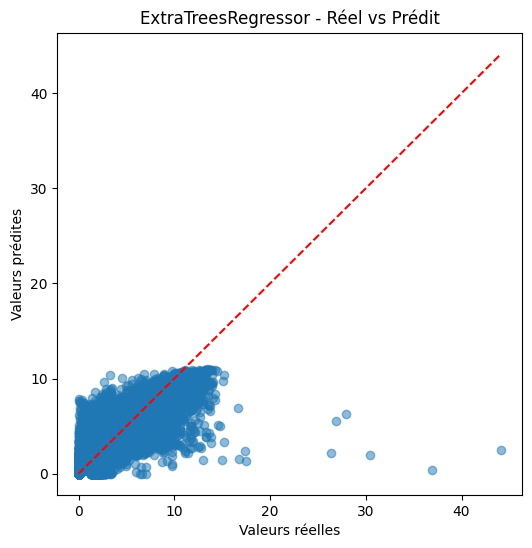

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_etr, y_pred_etr, alpha=0.5)
plt.plot([y_test_etr.min(), y_test_etr.max()],
         [y_test_etr.min(), y_test_etr.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("ExtraTreesRegressor - Réel vs Prédit")
plt.show()

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_etr, y_pred_etr, alpha=0.5)
plt.plot([y_test_etr.min(), y_test_etr.max()],
         [y_test_etr.min(), y_test_etr.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("ExtraTreesRegressor - Réel vs Prédit")
plt.show()

# RandomForrestRegressor

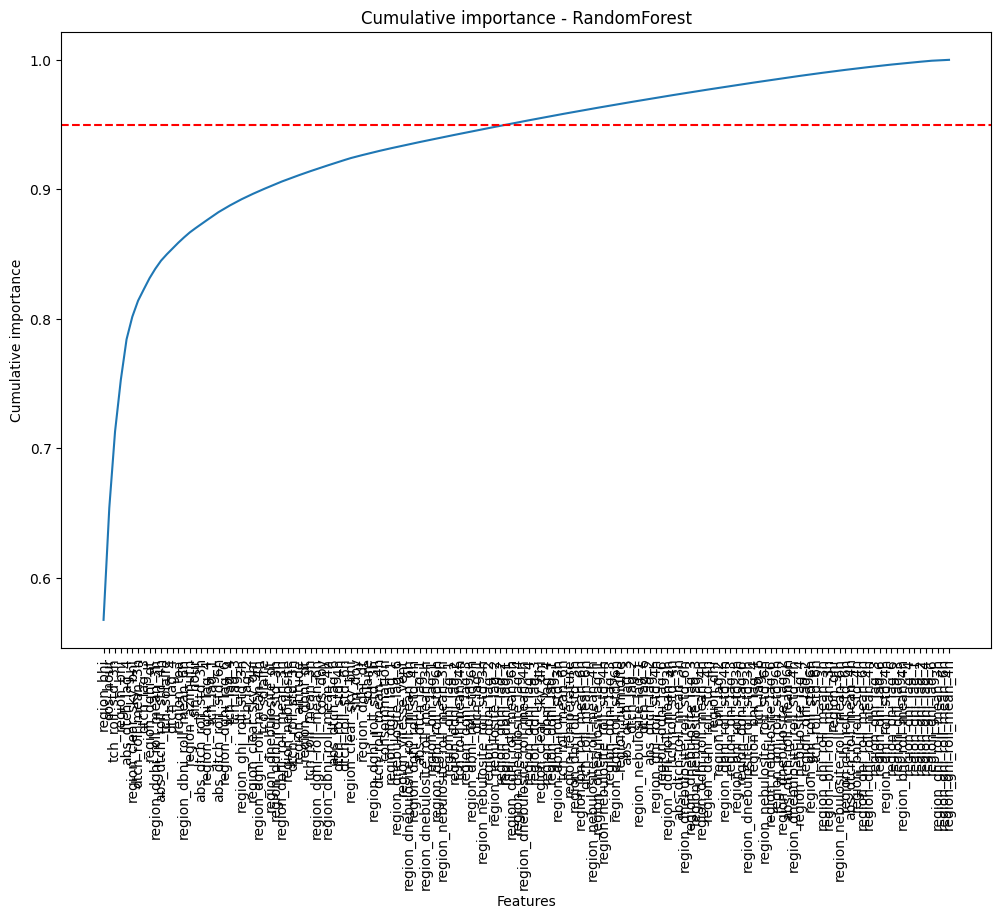

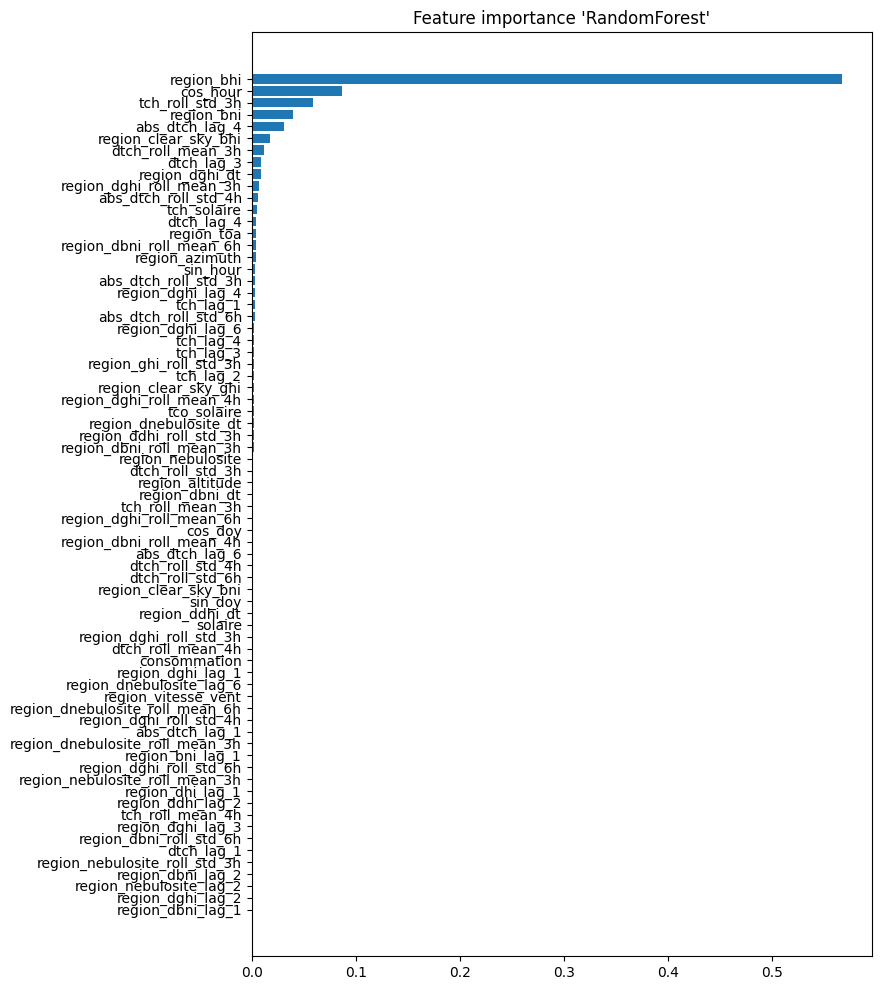

Fitting 3 folds for each of 350 candidates, totalling 1050 fits
Meilleurs paramètres RandomForest :
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 50}
Meilleur score CV (MAE) : 0.5455153758405697


In [216]:

importance_rf = variables_importantes(RandomForestRegressor, X_train, y_train)

importance_rf = importance_rf.sort_values(ascending=False)

cum_importance_rf = importance_rf.cumsum() / importance_rf.sum()

selected_features_rf = cum_importance_rf[cum_importance_rf <= 0.95].index

# sécurité
if len(selected_features_rf) == 0:
    selected_features_rf = importance_rf.index[:1]


plt.figure(figsize=(12,8))
plt.plot(cum_importance_rf.index, cum_importance_rf)
plt.axhline(0.95, color='red', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.title("Cumulative importance - RandomForest")
plt.show()


plt.figure(figsize=(8,12))
plt.barh(
    selected_features_rf,
    importance_rf[selected_features_rf] / importance_rf.sum()
)
plt.gca().invert_yaxis()
plt.title("Feature importance 'RandomForest'")
plt.show()


# Validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=3)

# Modèle RandomForest
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Espace de recherche
param_dist_rf = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [7, 10, 15, 20, 50],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.7, 1.0]
}

search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=350,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# entraînement
search_rf.fit(X_valid[selected_features_rf], y_valid)


print("Meilleurs paramètres RandomForest :")
print(search_rf.best_params_)

print("Meilleur score CV (MAE) :", -search_rf.best_score_)


with open("search_rf_pickle.pkl", mode="bw") as f:
    pickle.dump(search_rf, f)

with open("search_rf_pickle.pkl", "rb") as f:
    search_rf = pickle.load(f)


--- Résultats RandomForrestRegressor ---
MAE         : 0.48627606846484156
MAE relatif : 20.205%
RMSE        : 1.1075463088632542
R² train    : 0.9832536532485784
R² test     : 0.8861545669300054


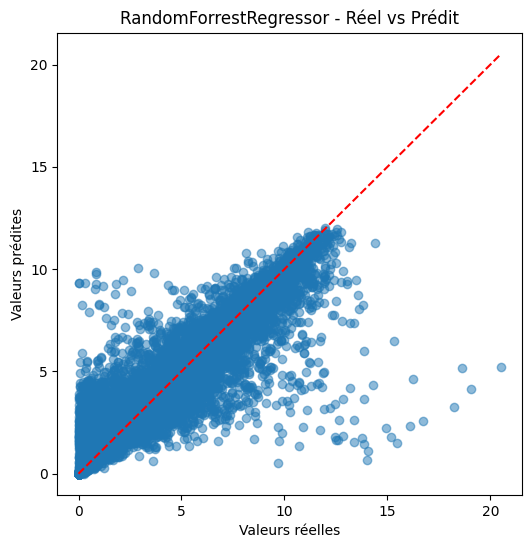

In [220]:
# Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_rf = pd.concat([X_train[selected_features_rf], X_valid[selected_features_rf]])
y_train_rf = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_rf = X_test[selected_features_rf].copy()
y_test_rf = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params_rf = search_rf.best_params_

# Initialisation du modèle Random Forest de régression
final_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params_rf
)

# Entraînement du modèle
final_rf.fit(X_train_rf, y_train_rf)

# Prédiction sur le jeu de test/train
y_pred_rf = final_rf.predict(X_test_rf)
y_pred_train_rf = final_rf.predict(X_train_rf)

# Évaluation
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_test_rf = r2_score(y_test_rf, y_pred_rf)
r2_train_rf = r2_score(y_train_rf, y_pred_train_rf)
mae_rel_rf = mae_rf / y_test_rf.mean() * 100

print("\n--- Résultats RandomForrestRegressor ---")
print("MAE         :", mae_rf)
print(f"MAE relatif : {round(mae_rel_rf, 3)}%")
print("RMSE        :", rmse_rf)
print("R² train    :", r2_train_rf)
print("R² test     :", r2_test_rf)

plt.figure(figsize=(6,6))
plt.scatter(y_test_rf, y_pred_rf, alpha=0.5)
plt.plot([y_test_rf.min(), y_test_rf.max()],
         [y_test_rf.min(), y_test_rf.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("RandomForrestRegressor - Réel vs Prédit")
plt.show()

In [221]:
test.loc[test.target > 15, ['region_ghi', 'tch_solaire', 'target']]

,region_ghi,tch_solaire,target
datetime_utc,,,
2024-03-18 09:30:00+00:00,230.71,43.72,15.30
2024-04-05 11:30:00+00:00,412.75,74.32,15.47
2024-04-12 10:30:00+00:00,414.13,74.24,15.17
2024-04-16 09:00:00+00:00,350.27,47.65,19.05
2024-04-20 12:30:00+00:00,444.12,81.08,16.08
2024-05-18 09:30:00+00:00,396.90,64.82,16.74
2024-06-10 13:30:00+00:00,411.99,74.85,18.22
2024-06-19 09:30:00+00:00,243.26,37.01,16.22
2024-06-19 13:00:00+00:00,242.83,41.72,18.62


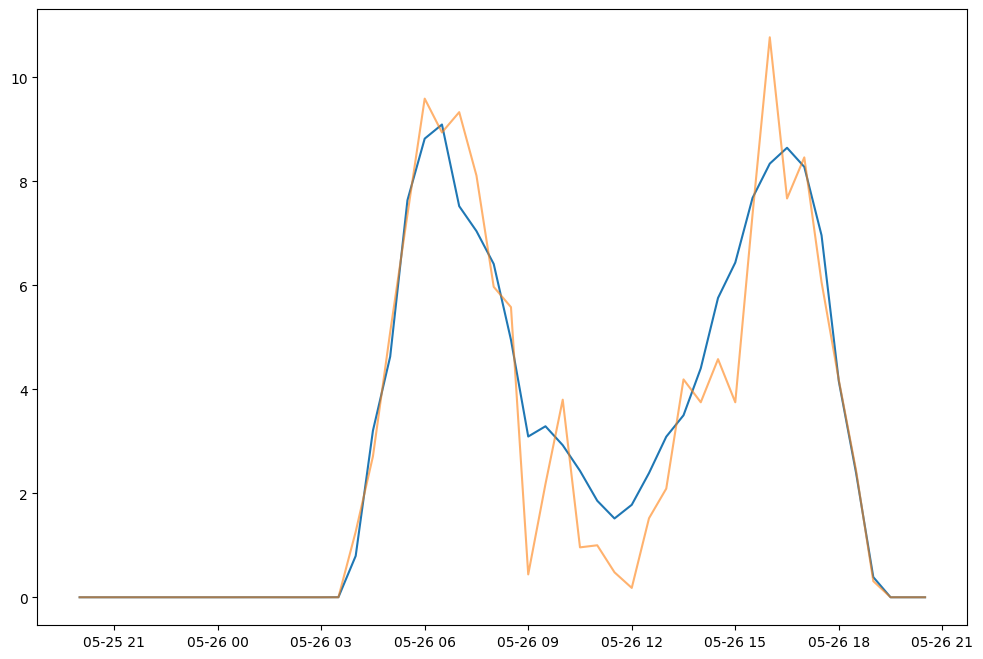

In [237]:
plt.figure(figsize=(12,8))
plt.plot(y_test.index[7000:7050], y_pred_rf[7000:7050])
plt.plot(y_test.index[7000:7050], y_test[7000:7050], alpha=0.6)

In [250]:
why_df = pd.DataFrame(y_pred_rf, index=y_test.index, columns=['y_pred_rf'])
compare_df = pd.concat([why_df,y_test], axis=1)
compare_df.head()
compare_df.loc[np.abs(compare_df.y_pred_rf-compare_df.target)>10]
final_rf.apply

,y_pred_rf,target
datetime_utc,,
2024-04-01 11:30:00+00:00,1.53,13.38
2024-04-05 11:30:00+00:00,1.51,15.47
2024-04-12 10:30:00+00:00,1.79,15.17
2024-04-16 09:00:00+00:00,4.13,19.05
2024-04-20 12:30:00+00:00,2.32,16.08
2024-05-18 09:30:00+00:00,2.57,16.74
2024-05-31 11:30:00+00:00,1.11,14.08
2024-06-01 10:00:00+00:00,1.75,13.78
2024-06-01 10:30:00+00:00,2.63,13.38


def variables_importantes_svr(model_class, X_train, y_train, random_state=42):
    """Calcule l'importance des variables pour un modèle SVR donné."""

    # Instanciation du modèle
    model = model_class()

    # Entraînement
    model.fit(X_train, y_train)

    # Importance par permutation
    result = permutation_importance(
        model,
        X_train,
        y_train,
        n_repeats=10,
        random_state=random_state,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    importance = pd.Series(
        result.importances_mean,
        index=X_train.columns
    ).sort_values(ascending=False)

    return importance

importance_svr = variables_importantes_svr(SVR, X_train_scaled, y_train)

importance_svr = importance_svr.sort_values(ascending=False)

# garder seulement les importances positives
importance_svr = importance_svr[importance_svr > 0]

cum_importance_svr = importance_svr.cumsum() / importance_svr.sum()

selected_features_svr = cum_importance_svr[cum_importance_svr <= 0.95].index


plt.figure(figsize=(12,8))
plt.plot(cum_importance_svr.index, cum_importance_svr)
plt.axhline(0.95, color='red', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel("Cumulative importance")
plt.xlabel("Features")
plt.title("Cumulative importance - SVR")
plt.show()

plt.figure(figsize=(8,12))
plt.barh(selected_features_svr, importance_svr[selected_features_svr]/importance_svr.sum())
plt.gca().invert_yaxis()
plt.title("Feature importance 'svr'")
plt.show()


In [ ]:
# selected_features_svr = ['tch_lag_3', 'tch_lag_1', 'tch_lag_2', 'dtch_lag_1', 'dghi_dt',
#        'dghi_lag_1', 'clear_sky_dhi_region', 'clear_sky_dni_region',
#        'toa_irradiance_region', 'dhi_region', 'cos_doy', 'sin_hour',
#        'dni_region', 'clear_sky_ghi_region', 'ghi_region',
#        'clear_sky_bhi_region', 'dghi_lag_2', 'cos_hour', 'ghi_lag_1',
#        'ghi_lag_3', 'bhi_region', 'dtch_lag_2', 'dghi_lag_3', 'ghi_lag_2',
#        'solar_altitude_region', 'cloud_cover_region', 'cloud_lag_1',
#        'cloud_lag_2', 'dtch_lag_3']

| Paramètre | Explication                                                                                                                                                                                                                                                                                               |
| --------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `kernel`  | Fonction noyau utilisée pour transformer les données dans un espace de dimension plus élevée afin de modéliser des relations non linéaires. Ici `rbf` (Radial Basis Function) est très courant car il permet de capturer des relations complexes entre les variables.                                     |
| `C`       | Paramètre de régularisation qui contrôle le compromis entre la complexité du modèle et l’erreur d’entraînement. Une grande valeur de `C` cherche à minimiser l’erreur sur les données d’entraînement mais peut provoquer du surapprentissage, tandis qu’une petite valeur rend le modèle plus régularisé. |
| `epsilon` | Largeur de la **zone de tolérance** autour de la prédiction dans laquelle les erreurs ne sont pas pénalisées. Une valeur plus grande rend le modèle moins sensible aux petites erreurs et peut améliorer la généralisation.                                                                               |
| `gamma`   | Paramètre spécifique aux noyaux comme `rbf`. Il contrôle l’influence d’un point d’entraînement sur la prédiction. Une grande valeur signifie que l’influence est très locale (modèle plus complexe), tandis qu’une petite valeur rend l’influence plus globale (modèle plus lisse).                       |



# Validation croisée adaptée aux séries temporelles
tscv = TimeSeriesSplit(n_splits=5)

# Modèle SVR
svr = SVR(kernel='rbf',
          gamma='scale')

# Espace de recherche réduit et raisonnable
param_dist_svr = {
    "C": [0.01, 0.1, 1, 10, 50],
    "epsilon": [0.001, 0.01, 0.05, 0.1, 0.2]
}

# Recherche aléatoire
search_svr = RandomizedSearchCV(
    estimator=svr,
    param_distributions=param_dist_svr,
    n_iter=25,                
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# Entraînement
search_svr.fit(X_train_scaled[selected_features_svr], y_train)

# Résultats
print("Meilleurs paramètres SVR :")
print(search_svr.best_params_)

print("Meilleur score CV (MAE) :", -search_svr.best_score_)

# Sauvegarde
with open("search_svr_pickle.pkl", mode="bw") as f:
    pickle.dump(search_svr, f)

# Rechargement
with open("search_svr_pickle.pkl", "rb") as f:
    search_svr = pickle.load(f)


# # Construction des variables explicatives (X) et de la cible (y) pour l'entraînement
X_train_svr = pd.concat([X_train_scaled[selected_features_svr], X_valid_scaled[selected_features_svr]])
y_train_svr = pd.concat([y_train, y_valid])

# Construction du jeu de test
X_test_svr = X_test_scaled[selected_features_svr].copy()
y_test_svr = y_test.copy()

# Récupération des meilleurs hyperparamètres issus de la recherche
best_params = search_svr.best_params_

# Initialisation du modèle SVM de régression
final_svr = SVR(
    kernel='rbf',
    **best_params
)

# Entraînement du modèle
final_svr.fit(X_train_svr, y_train_svr)

# Prédiction sur le jeu de test
y_pred = final_svr.predict(X_test_svr)

# Évaluation des performances sur le jeu de test
print("MAE  :", mean_absolute_error(y_test_svr, y_pred))
print(f"MAE relatif : {round(mean_absolute_error(y_test_svr, y_pred) / y_test_svr.mean() * 100, 3)}%")
print("RMSE :", np.sqrt(mean_squared_error(y_test_svr, y_pred)))
print("R²   :", r2_score(y_test_svr, y_pred))


# Prédictions
y_pred_svr = final_svr.predict(X_test_svr)
y_pred_train_svr = final_svr.predict(X_train_svr)

# Évaluation
mae_svr = mean_absolute_error(y_test_svr, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test_svr, y_pred_svr))
r2_test_svr = r2_score(y_test_svr, y_pred_svr)
r2_train_svr = r2_score(y_train_svr, y_pred_train_svr)
mae_rel_svr = mae_svr / y_test_svr.mean() * 100

print("\n--- Résultats SVR ---")
print("MAE         :", mae_svr)
print(f"MAE relatif : {round(mae_rel_svr, 3)}%")
print("RMSE        :", rmse_svr)
print("R² train    :", r2_train_svr)
print("R² test     :", r2_test_svr)

plt.figure(figsize=(6,6))
plt.scatter(y_test_svr, y_pred_svr, alpha=0.5)
plt.plot([y_test_svr.min(), y_test_svr.max()],
         [y_test_svr.min(), y_test_svr.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("SVR - Réel vs Prédit")
plt.show()

results = pd.DataFrame({
    "y_true": y_test_rf,
    "y_pred": y_pred
}, index=y_test_rf.index)

results["residual"] = results["y_true"] - results["y_pred"]
results["abs_residual"] = np.abs(results["residual"])

outliers = results.sort_values("abs_residual", ascending=False).head(20)

outliers_full = X_test_rf.loc[outliers.index].copy()
outliers_full = outliers_full.join(outliers)

test.loc[outliers.index][['tch_lag_1', 'target_variability', 'hour', 'month', 'ghi_region']]

In [ ]:
# # Évaluation
# mae = mean_absolute_error(y_test_etr, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test_etr, y_pred))
# r2_test = r2_score(y_test_etr, y_pred)
# r2_train = r2_score(y_train_etr, y_pred_train)
# mae_rel = mae / y_test_etr.mean() * 100

# print("\n--- Résultats Extra Trees Regressor ---")
# print("MAE         :", mae)
# print(f"MAE relatif : {round(mae_rel, 3)}%")
# print("RMSE        :", rmse)
# print("R² train    :", r2_train)
# print("R² test     :", r2_test)

results = []

models = {
    "lgbm": final_lgbm,
    "xgb": final_xgb,
    "svr": final_svr,
    "rf": final_rf,
    "etr": final_etr
}

X_tests = {
    "lgbm": X_test_lgbm,
    "xgb": X_test_xgb,
    "svr": X_test_svr,
    "rf": X_test_rf,
    "etr": X_test_etr
}

X_trains = {
    "lgbm": X_train_lgbm,
    "xgb": X_train_xgb,
    "svr": X_train_svr,
    "rf": X_train_rf,
    "etr": X_train_etr
}

y_trains = {
    "lgbm": y_train_lgbm,
    "xgb": y_train_xgb,
    "svr": y_train_svr,
    "rf": y_train_rf,
    "etr": y_train_etr
}

y_tests = {
    "lgbm": y_test_lgbm,
    "xgb": y_test_xgb,
    "svr": y_test_svr,
    "rf": y_test_rf,
    "etr": y_test_etr
}


for name, model in models.items():

    X_test = X_tests[name]
    X_train = X_trains[name]
    y_test = y_tests[name]
    y_train = y_trains[name]

    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_test = r2_score(y_test, y_pred)
    r2_train = r2_score(y_train, y_pred_train)
    mae_rel = mae / y_test.mean() * 100

    results.append({
        "Model": name,
        "MAE": mae,
        "MAE_rel (%)": mae_rel,
        "RMSE": rmse,
        "R2_train": r2_train,
        "R2_test": r2_test
    })

results_df = pd.DataFrame(results)

results_df.set_index('Model').sort_values(by='MAE')